In [ ]:
ch!pip install pandas numpy scikit-learn tensorflow

In [ ]:

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import pickle

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception as e:
    tf = None
    print("TensorFlow not available. Install with: pip install tensorflow")

# --- Parameters ---
LABS_CSV = "relevant_labs.csv"
DIAG_CSV = "diagnoses_icd.csv"
MODEL_OUT = "lstm_ami_model.h5"
SCALER_OUT = "scaler_and_weights.pkl"
N_TIMESTEPS = 10

# Preferred biomarkers list
PREFERRED_BIOMARKERS = [
    "hs-cTn I","CK-MB","CRP","IL-6","TNF-α",
    "MPO","PTX-3","suPAR","NGAL","NLR","MPV","PLR"
]

# --- Helpers ---
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    for col in df.columns:
        if col.lower() in [x.lower() for x in candidates]:
            return col
    return None

def detect_ami_codes(s):
    if pd.isna(s):
        return False
    s = str(s).upper()
    if s.startswith("410") or s.startswith("I21"):
        return True
    if "AMI" in s or "ACUTE MYOCARDIAL" in s or "MYOCARDIAL INFARCTION" in s:
        return True
    return False

# --- Load data ---
labs = pd.read_csv(LABS_CSV)
diags = pd.read_csv(DIAG_CSV)

# Infer columns
patient_col = find_col(labs,["patient_id","subject_id","hadm_id"])
time_col_lab = find_col(labs,["charttime","time","datetime","date"])
lab_name_col = find_col(labs,["lab_name","itemid","test_name","component","test"])
lab_value_col = find_col(labs,["value","lab_value","value_num","test_value","result"])

labs = labs.rename(columns={patient_col:"patient_id", lab_name_col:"lab_name", lab_value_col:"value"})
if time_col_lab: labs = labs.rename(columns={time_col_lab:"charttime"})
labs["value"] = pd.to_numeric(labs["value"], errors="coerce")

patient_col_diag = find_col(diags,["patient_id","subject_id","hadm_id"])
diag_code_col = find_col(diags,["icd_code","code","diagnosis"])
diags = diags.rename(columns={patient_col_diag:"patient_id", diag_code_col:"icd_code"})

# Labels
diags["is_ami"] = diags["icd_code"].apply(detect_ami_codes)
ami_patients = set(diags.loc[diags["is_ami"],"patient_id"].unique())

# --- Biomarker set ---
all_biomarkers = labs["lab_name"].unique().tolist()
use_biomarkers = [b for b in PREFERRED_BIOMARKERS if b in all_biomarkers]

if len(use_biomarkers) == 0:
    print("Preferred biomarkers not found. Selecting top 20 features from RandomForest...")
    labs_sorted = labs.sort_values(["patient_id","charttime"])
    last_vals = labs_sorted.groupby(["patient_id","lab_name"]) ["value"].last().reset_index()
    pivot = last_vals.pivot(index="patient_id", columns="lab_name", values="value")
    pivot = pivot.fillna(pivot.median())
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(pivot.values, [1 if pid in ami_patients else 0 for pid in pivot.index])
    top_features = rf.feature_importances_.argsort()[::-1]
    use_biomarkers = pivot.columns[top_features[:20]].tolist()
    print("Using top RF features:", use_biomarkers)
else:
    print("Using preferred biomarkers:", use_biomarkers)

# --- Build patient sequences with consistent feature set ---
X_seqs, y_labels = [], []

for pid, group in labs.groupby("patient_id"):
    group = group.sort_values("charttime")
    pivoted = group.pivot_table(index="charttime", columns="lab_name", values="value")
    for b in use_biomarkers:
        if b not in pivoted.columns:
            pivoted[b] = np.nan
    pivoted = pivoted[use_biomarkers]

    seq = pivoted.tail(N_TIMESTEPS).values
    if seq.shape[0] < N_TIMESTEPS:
        pad = np.full((N_TIMESTEPS - seq.shape[0], len(use_biomarkers)), np.nan)
        seq = np.vstack([pad, seq])

    X_seqs.append(seq)
    y_labels.append(1 if pid in ami_patients else 0)

X = np.array(X_seqs)
y = np.array(y_labels)

# Impute missing values with median per feature
for f in range(X.shape[2]):
    col = X[:,:,f].flatten()
    median = np.nanmedian(col)
    X[:,:,f] = np.where(np.isnan(X[:,:,f]), median, X[:,:,f])

print("Final data shape:", X.shape)

# --- Train/test split and scaling ---
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
ns,nt,nf = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape((ns*nt,nf))
X_test_2d = X_test.reshape((X_test.shape[0]*X_test.shape[1],nf))
scaler.fit(X_train_2d)
X_train_scaled = scaler.transform(X_train_2d).reshape((ns,nt,nf))
X_test_scaled = scaler.transform(X_test_2d).reshape((X_test.shape[0],nt,nf))

# --- LSTM model ---
if tf is None:
    raise ImportError("TensorFlow required.")

from tensorflow.keras import backend as K
K.clear_session()
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(nt,nf)))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

es = EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)
model.fit(X_train_scaled,y_train,validation_split=0.2,epochs=30,batch_size=32,callbacks=[es],verbose=1)

preds = model.predict(X_test_scaled).ravel()
print('AUC:', roc_auc_score(y_test, preds))
print('Accuracy:', accuracy_score(y_test, (preds>0.5).astype(int)))
print(classification_report(y_test,(preds>0.5).astype(int)))

model.save(MODEL_OUT)
with open(SCALER_OUT,'wb') as f:
    pickle.dump({'scaler':scaler,'biomarkers':use_biomarkers},f)

print('Saved model to', MODEL_OUT)
print('Saved scaler/weights to', SCALER_OUT)

Preferred biomarkers not found. Selecting top 20 features from RandomForest...
Using top RF features: [50911, 50908, 50907, 50954, 50912, 50863, 51222, 51256, 50811, 50904, 51221, 50902, 51277, 51248, 51265, 51279, 52075, 51301, 51244, 51254]
Final data shape: (3991, 10, 20)
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - AUC: 0.6232 - loss: 0.4405 - val_AUC: 0.7766 - val_loss: 0.1667
Epoch 2/30
22/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - AUC: 0.7763 - loss: 0.1400

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.8281 - loss: 0.1294 - val_AUC: 0.8211 - val_loss: 0.1547
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.8412 - loss: 0.1203 - val_AUC: 0.8165 - val_loss: 0.1556
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.8997 - loss: 0.1030 - val_AUC: 0.8279 - val_loss: 0.1534
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9249 - loss: 0.1007 - val_AUC: 0.8192 - val_loss: 0.1579
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.9160 - loss: 0.0972 - val_AUC: 0.8221 - val_loss: 0.1569
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.9335 - loss: 0.0767 - val_AUC: 0.8092 - val_loss: 0.1591
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9070 - loss: 0.0940 - val_AUC: 0.8153 - val_loss: 0.1630
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - AUC: 0.9544 - loss: 0.0754 - val_AUC: 0.7917 - val_loss: 0.1738
Epoch 10/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - AUC: 0.9550 - loss: 0.07

 0.7521186440677966
Accuracy: 0.9361702127659575
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       767
           1       0.23      0.25      0.24        32

    accuracy                           0.94       799
   macro avg       0.60      0.61      0.60       799
weighted avg       0.94      0.94      0.94       799

Saved model to lstm_ami_model.h5
Saved scaler/weights to scaler_and_weights.pkl


 ***LSTM MODEL***

In [ ]:
"""
AMI prediction pipeline with true temporal sequences (LSTM)

- Uses a fixed window of lab events per patient (N_TIMESTEPS)
- Focuses on a clinically relevant biomarker set:
  hs-cTn I, CK-MB, CRP, IL-6, TNF-α, MPO, PTX-3, suPAR, NGAL, NLR, MPV, PLR
- If these biomarkers are missing from the dataset, falls back to top 20 features from RandomForest importance
- Adds class weighting during training to handle imbalance
- Prints classification reports at multiple thresholds (0.5, 0.4, 0.3, 0.2)
"""

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import pickle

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception as e:
    tf = None
    print("TensorFlow not available. Install with: pip install tensorflow")

# --- Parameters ---
LABS_CSV = "relevant_labs.csv"
DIAG_CSV = "diagnoses_icd.csv"
MODEL_OUT = "lstm_ami_model.h5"
SCALER_OUT = "scaler_and_weights.pkl"
N_TIMESTEPS = 10

# Preferred biomarkers list
PREFERRED_BIOMARKERS = [
    "hs-cTn I","CK-MB","CRP","IL-6","TNF-α",
    "MPO","PTX-3","suPAR","NGAL","NLR","MPV","PLR"
]

# --- Helpers ---
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    for col in df.columns:
        if col.lower() in [x.lower() for x in candidates]:
            return col
    return None

def detect_ami_codes(s):
    if pd.isna(s):
        return False
    s = str(s).upper()
    if s.startswith("410") or s.startswith("I21"):
        return True
    if "AMI" in s or "ACUTE MYOCARDIAL" in s or "MYOCARDIAL INFARCTION" in s:
        return True
    return False

# --- Load data ---
labs = pd.read_csv(LABS_CSV)
diags = pd.read_csv(DIAG_CSV)

# Infer columns
patient_col = find_col(labs,["patient_id","subject_id","hadm_id"])
time_col_lab = find_col(labs,["charttime","time","datetime","date"])
lab_name_col = find_col(labs,["lab_name","itemid","test_name","component","test"])
lab_value_col = find_col(labs,["value","lab_value","value_num","test_value","result"])

labs = labs.rename(columns={patient_col:"patient_id", lab_name_col:"lab_name", lab_value_col:"value"})
if time_col_lab: labs = labs.rename(columns={time_col_lab:"charttime"})
labs["value"] = pd.to_numeric(labs["value"], errors="coerce")

patient_col_diag = find_col(diags,["patient_id","subject_id","hadm_id"])
diag_code_col = find_col(diags,["icd_code","code","diagnosis"])
diags = diags.rename(columns={patient_col_diag:"patient_id", diag_code_col:"icd_code"})

# Labels
diags["is_ami"] = diags["icd_code"].apply(detect_ami_codes)
ami_patients = set(diags.loc[diags["is_ami"],"patient_id"].unique())

# --- Biomarker set ---
all_biomarkers = labs["lab_name"].unique().tolist()
use_biomarkers = [b for b in PREFERRED_BIOMARKERS if b in all_biomarkers]

if len(use_biomarkers) == 0:
    print("Preferred biomarkers not found. Selecting top 20 features from RandomForest...")
    labs_sorted = labs.sort_values(["patient_id","charttime"])
    last_vals = labs_sorted.groupby(["patient_id","lab_name"]) ["value"].last().reset_index()
    pivot = last_vals.pivot(index="patient_id", columns="lab_name", values="value")
    pivot = pivot.fillna(pivot.median())
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(pivot.values, [1 if pid in ami_patients else 0 for pid in pivot.index])
    top_features = rf.feature_importances_.argsort()[::-1]
    use_biomarkers = pivot.columns[top_features[:20]].tolist()
    print("Using top RF features:", use_biomarkers)
else:
    print("Using preferred biomarkers:", use_biomarkers)

# --- Build patient sequences with consistent feature set ---
X_seqs, y_labels = [], []

for pid, group in labs.groupby("patient_id"):
    group = group.sort_values("charttime")
    pivoted = group.pivot_table(index="charttime", columns="lab_name", values="value")
    for b in use_biomarkers:
        if b not in pivoted.columns:
            pivoted[b] = np.nan
    pivoted = pivoted[use_biomarkers]

    seq = pivoted.tail(N_TIMESTEPS).values
    if seq.shape[0] < N_TIMESTEPS:
        pad = np.full((N_TIMESTEPS - seq.shape[0], len(use_biomarkers)), np.nan)
        seq = np.vstack([pad, seq])

    X_seqs.append(seq)
    y_labels.append(1 if pid in ami_patients else 0)

X = np.array(X_seqs)
y = np.array(y_labels)

# Impute missing values with median per feature
for f in range(X.shape[2]):
    col = X[:,:,f].flatten()
    median = np.nanmedian(col)
    X[:,:,f] = np.where(np.isnan(X[:,:,f]), median, X[:,:,f])

print("Final data shape:", X.shape)

# --- Train/test split and scaling ---
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
ns,nt,nf = X_train.shape

scaler = StandardScaler()
X_train_2d = X_train.reshape((ns*nt,nf))
X_test_2d = X_test.reshape((X_test.shape[0]*X_test.shape[1],nf))
scaler.fit(X_train_2d)
X_train_scaled = scaler.transform(X_train_2d).reshape((ns,nt,nf))
X_test_scaled = scaler.transform(X_test_2d).reshape((X_test.shape[0],nt,nf))

# --- LSTM model ---
if tf is None:
    raise ImportError("TensorFlow required.")

from tensorflow.keras import backend as K
K.clear_session()
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(nt,nf)))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

es = EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)

# compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, class_weights))

model.fit(X_train_scaled,y_train,validation_split=0.2,epochs=30,batch_size=32,callbacks=[es],verbose=1,class_weight=class_weights)

preds = model.predict(X_test_scaled).ravel()
print('AUC:', roc_auc_score(y_test, preds))
print('Accuracy (thr=0.5):', accuracy_score(y_test, (preds>0.5).astype(int)))
print("\nReports at different thresholds:")
for thr in [0.5,0.4,0.3,0.2]:
    print(f"\nThreshold {thr}")
    y_pred_thr = (preds>thr).astype(int)
    print(classification_report(y_test,y_pred_thr))

model.save(MODEL_OUT)
with open(SCALER_OUT,'wb') as f:
    pickle.dump({'scaler':scaler,'biomarkers':use_biomarkers},f)

print('Saved model to', MODEL_OUT)
print('Saved scaler/weights to', SCALER_OUT)


Preferred biomarkers not found. Selecting top 20 features from RandomForest...
Using top RF features: [50911, 50908, 50912, 50910, 50809, 50811, 50863, 51221, 51100, 50905, 50904, 50907, 50954, 51279, 51200, 51254, 51265, 51248, 50902, 50971]
Final data shape: (979, 10, 20)
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - AUC: 0.6721 - loss: 0.6562 - val_AUC: 0.8206 - val_loss: 0.6220
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - AUC: 0.9310 - loss: 0.5044 - val_AUC: 0.8664 - val_loss: 0.5366
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - AUC: 0.9261 - loss: 0.4016 - val_AUC: 0.9178 - val_loss: 0.3619
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - AUC: 0.9727 - loss: 0.1914 - val_AUC: 0.8960 - val_loss: 0.2648
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - AUC: 0.9877 - loss: 0.1493 - val_AUC: 0.8292 - val_loss: 0.3498
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - AUC: 0.9482 - loss: 0.1071 - val_AUC: 0.8390 - val_loss: 0.2993
Epoch 7/30
20/20 ━━━━━━

AUC: 0.8193701723113488
Accuracy (thr=0.5): 0.9183673469387755

Reports at different thresholds:

Threshold 0.5
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       187
           1       0.23      0.33      0.27         9

    accuracy                           0.92       196
   macro avg       0.60      0.64      0.61       196
weighted avg       0.93      0.92      0.93       196


Threshold 0.4
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       187
           1       0.23      0.33      0.27         9

    accuracy                           0.92       196
   macro avg       0.60      0.64      0.61       196
weighted avg       0.93      0.92      0.93       196


Threshold 0.3
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       187
           1       0.23      0.33      0.27         9

    accuracy                           0

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


--- Plotting Precision-Recall Curve ---
Average Precision (AP / AUC-PR): 0.2401
Best Threshold (by F1-score): 0.0038
  > F1: 0.4138
  > Precision: 0.3000
  > Recall: 0.6667


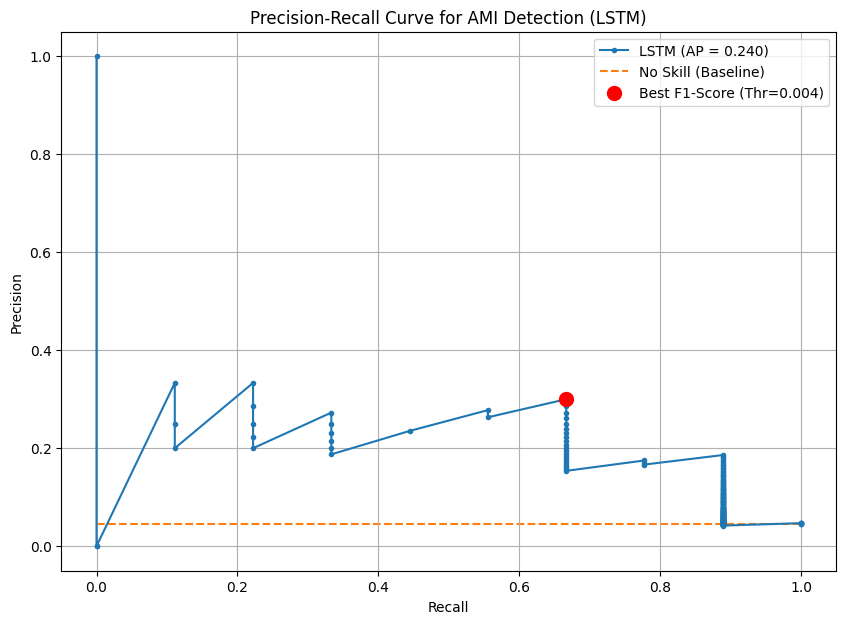

AUC: 0.8193701723113488
Accuracy (thr=0.5): 0.9183673469387755

Reports at different thresholds:

Threshold 0.5000
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       187
           1       0.23      0.33      0.27         9

    accuracy                           0.92       196
   macro avg       0.60      0.64      0.61       196
weighted avg       0.93      0.92      0.93       196


Threshold 0.4000
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       187
           1       0.23      0.33      0.27         9

    accuracy                           0.92       196
   macro avg       0.60      0.64      0.61       196
weighted avg       0.93      0.92      0.93       196


Threshold 0.3000
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       187
           1       0.23      0.33      0.27         9

    accuracy                   

In [ ]:
# --- Plot Precision-Recall Curve ---
print("\n--- Plotting Precision-Recall Curve ---")

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, preds)

# Calculate Average Precision (AP), which is the area under the PR curve
ap = average_precision_score(y_test, preds)
print(f"Average Precision (AP / AUC-PR): {ap:.4f}")

# Calculate F1-score for all thresholds
# We add + 1e-9 to avoid division by zero
# We use [:-1] to align with the 'thresholds' array size
f1_scores = (2 * recall[:-1] * precision[:-1]) / (recall[:-1] + precision[:-1] + 1e-9)

# Find the threshold that gives the max F1
ix = np.argmax(f1_scores)
best_threshold = thresholds[ix]
print(f"Best Threshold (by F1-score): {best_threshold:.4f}")
print(f"  > F1: {f1_scores[ix]:.4f}")
print(f"  > Precision: {precision[ix]:.4f}")
print(f"  > Recall: {recall[ix]:.4f}")

# Plot the PR curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, marker='.', label=f'LSTM (AP = {ap:.3f})', zorder=2)

# Plot the "no skill" line (random classifier)
no_skill = (y_test == 1).sum() / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill (Baseline)', zorder=1)

# Plot the optimal F1 point
plt.scatter(recall[ix], precision[ix], marker='o', color='red', s=100,
            label=f'Best F1-Score (Thr={best_threshold:.3f})', zorder=3)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for AMI Detection (LSTM)')
plt.legend()
plt.grid(True)
plt.show()

# --- Continue with existing evaluation ---
print('AUC:', roc_auc_score(y_test, preds))
print('Accuracy (thr=0.5):', accuracy_score(y_test, (preds>0.5).astype(int)))

# --- MODIFIED: Loop to include the new "best" threshold ---
print("\nReports at different thresholds:")
all_thresholds_to_check = sorted(list(set([0.5, 0.4, 0.3, 0.2] + [best_threshold])), reverse=True)

for thr in all_thresholds_to_check:
    print(f"\nThreshold {thr:.4f}" + (" (Best F1)" if thr == best_threshold else ""))
    y_pred_thr = (preds > thr).astype(int)
    print(classification_report(y_test, y_pred_thr))

## ***LSTM + SMOTE MODEL***

In [ ]:
"""
AMI prediction pipeline (LSTM + SMOTE)

- Uses a fixed window of lab events (N_TIMESTEPS)
- Correctly handles padding/masking using a dedicated PAD_VALUE
- Applies SMOTE to resample the minority (AMI) class in the training set
- Focuses on a clinically relevant biomarker set (or RF fallback)
- Prints classification reports at multiple thresholds
"""

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import pickle

# --- NEW Imports for Solution 1 ---
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    print("imbalanced-learn not found. Install with: pip install imbalanced-learn")
    SMOTE = None

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Masking, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.metrics import AUC as KerasAUC
    from tensorflow.keras import backend as K
except Exception as e:
    tf = None
    print("TensorFlow not available. Install with: pip install tensorflow")

# --- Parameters ---
# --- PATHS UPDATED ---
LABS_CSV = "/content/relevant_labs.csv"
DIAG_CSV = "/content/diagnoses_icd.csv"
# --- END PATHS ---
MODEL_OUT = "lstm_ami_model_smote.h5"
SCALER_OUT = "scaler_and_weights_smote.pkl"
N_TIMESTEPS = 10
PAD_VALUE = -999.0  # --- NEW: Dedicated value for padding

# Preferred biomarkers list
PREFERRED_BIOMARKERS = [
    "hs-cTn I","CK-MB","CRP","IL-6","TNF-α",
    "MPO","PTX-3","suPAR","NGAL","NLR","MPV","PLR"
]

# --- Helpers ---
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    for col in df.columns:
        if col.lower() in [x.lower() for x in candidates]:
            return col
    return None

def detect_ami_codes(s):
    if pd.isna(s):
        return False
    s = str(s).upper()
    if s.startswith("410") or s.startswith("I21"):
        return True
    if "AMI" in s or "ACUTE MYOCARDIAL" in s or "MYOCARDIAL INFARCTION" in s:
        return True
    return False

# --- Load data ---
print("Loading data...")
labs = pd.read_csv(LABS_CSV)
diags = pd.read_csv(DIAG_CSV)

# Infer columns
patient_col = find_col(labs,["patient_id","subject_id","hadm_id"])
time_col_lab = find_col(labs,["charttime","time","datetime","date"])
lab_name_col = find_col(labs,["lab_name","itemid","test_name","component","test"])
lab_value_col = find_col(labs,["value","lab_value","value_num","test_value","result"])

labs = labs.rename(columns={patient_col:"patient_id", lab_name_col:"lab_name", lab_value_col:"value"})
if time_col_lab: labs = labs.rename(columns={time_col_lab:"charttime"})
labs["value"] = pd.to_numeric(labs["value"], errors="coerce")

patient_col_diag = find_col(diags,["patient_id","subject_id","hadm_id"])
diag_code_col = find_col(diags,["icd_code","code","diagnosis"])
diags = diags.rename(columns={patient_col_diag:"patient_id", diag_code_col:"icd_code"})

# Labels
diags["is_ami"] = diags["icd_code"].apply(detect_ami_codes)
ami_patients = set(diags.loc[diags["is_ami"],"patient_id"].unique())

# --- Biomarker set ---
all_biomarkers = labs["lab_name"].unique().tolist()
use_biomarkers = [b for b in PREFERRED_BIOMARKERS if b in all_biomarkers]

if len(use_biomarkers) == 0:
    print("Preferred biomarkers not found. Selecting top 20 features from RandomForest...")
    labs_sorted = labs.sort_values(["patient_id","charttime"])
    last_vals = labs_sorted.groupby(["patient_id","lab_name"]) ["value"].last().reset_index()
    pivot = last_vals.pivot(index="patient_id", columns="lab_name", values="value")
    pivot = pivot.fillna(pivot.median())
    rf_labels = [1 if pid in ami_patients else 0 for pid in pivot.index]
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(pivot.values, rf_labels)
    top_features = rf.feature_importances_.argsort()[::-1]
    use_biomarkers = pivot.columns[top_features[:20]].tolist()
    print("Using top RF features:", use_biomarkers)
else:
    print("Using preferred biomarkers:", use_biomarkers)

# --- Build patient sequences with consistent feature set ---
print("Building patient sequences...")
X_seqs, y_labels = [], []

for pid, group in labs.groupby("patient_id"):
    group = group.sort_values("charttime")
    pivoted = group.pivot_table(index="charttime", columns="lab_name", values="value")
    for b in use_biomarkers:
        if b not in pivoted.columns:
            pivoted[b] = np.nan
    pivoted = pivoted[use_biomarkers]

    seq = pivoted.tail(N_TIMESTEPS).values

    # --- MODIFIED: Pad with PAD_VALUE, not nan ---
    if seq.shape[0] < N_TIMESTEPS:
        pad = np.full((N_TIMESTEPS - seq.shape[0], len(use_biomarkers)), PAD_VALUE)
        seq = np.vstack([pad, seq])

    X_seqs.append(seq)
    y_labels.append(1 if pid in ami_patients else 0)

X = np.array(X_seqs)
y = np.array(y_labels)

# --- MODIFIED: Impute missing values (np.nan), but *ignore* the PAD_VALUE ---
print("Imputing real missing values (NaN)...")
for f in range(X.shape[2]):
    col = X[:,:,f].flatten()

    # Create a masked array to calculate median, ignoring NaNs and PAD_VALUE
    col_masked = np.ma.masked_where((np.isnan(col)) | (col == PAD_VALUE), col)

    if np.ma.is_masked(col_masked) or col_masked.count() == 0:
        median = 0.0 # Fallback if all data is missing/padded
    else:
        median = np.ma.median(col_masked)

    # Replace only np.nan
    X[:,:,f] = np.where(np.isnan(X[:,:,f]), median, X[:,:,f])

print("Final data shape:", X.shape)
print(f"Total labels: {len(y)}, Positive (AMI): {np.sum(y)}")

# --- Train/test split and scaling ---
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
ns,nt,nf = X_train.shape
ns_test = X_test.shape[0]

scaler = StandardScaler()

# --- MODIFIED: Fit scaler only on non-padded data ---
# Reshape and filter out padding before fitting scaler
X_train_2d_fit = X_train.reshape((ns*nt, nf))
X_train_2d_fit = X_train_2d_fit[X_train_2d_fit[:, 0] != PAD_VALUE]

if X_train_2d_fit.shape[0] > 0:
    scaler.fit(X_train_2d_fit)
else:
    print("Warning: No non-padded data found to fit scaler.")

# Transform the full data (but only non-padded values)
X_train_scaled = X_train.copy().reshape(ns*nt, nf)
X_test_scaled = X_test.copy().reshape(ns_test*nt, nf)

# Get indices of non-padded data
train_idx_to_scale = X_train_scaled[:, 0] != PAD_VALUE
test_idx_to_scale = X_test_scaled[:, 0] != PAD_VALUE

# Scale only the non-padded data in place
X_train_scaled[train_idx_to_scale] = scaler.transform(X_train_scaled[train_idx_to_scale])
X_test_scaled[test_idx_to_scale] = scaler.transform(X_test_scaled[test_idx_to_scale])

# Reshape back to 3D
X_train_scaled = X_train_scaled.reshape(ns, nt, nf)
X_test_scaled = X_test_scaled.reshape(ns_test, nt, nf)

# --- NEW: Apply SMOTE to training data ---
if SMOTE is None:
    raise ImportError("imbalanced-learn is required for SMOTE.")

# SMOTE needs 2D data, so we flatten the time and feature dimensions
X_train_flattened = X_train_scaled.reshape((ns, nt * nf))

print(f"\nShape before SMOTE: {X_train_flattened.shape}")
print(f"Label distribution before SMOTE: {np.bincount(y_train)}")

# k_neighbors must be less than the number of positive samples
n_positive_samples = np.sum(y_train == 1)
smote_k = max(1, n_positive_samples - 1)
print(f"Using k_neighbors={smote_k} for SMOTE")

if n_positive_samples > 1:
    sm = SMOTE(random_state=42, k_neighbors=smote_k)
    X_train_res, y_train_res = sm.fit_resample(X_train_flattened, y_train)
else:
    print("Not enough positive samples to run SMOTE, using original training data.")
    X_train_res, y_train_res = X_train_flattened, y_train

print(f"Shape after SMOTE: {X_train_res.shape}")
print(f"Label distribution after SMOTE: {np.bincount(y_train_res)}")

# Reshape back to 3D for LSTM
X_train_res_3d = X_train_res.reshape((X_train_res.shape[0], nt, nf))


# --- LSTM model ---
if tf is None:
    raise ImportError("TensorFlow required.")

K.clear_session()
model = Sequential()
# --- MODIFIED: Use the correct PAD_VALUE for masking ---
model.add(Masking(mask_value=PAD_VALUE, input_shape=(nt,nf)))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# --- MODIFIED: Monitor PR-AUC, which is better for imbalanced data ---
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['AUC', KerasAUC(curve='PR', name='pr_auc')])

# --- MODIFIED: Monitor 'val_pr_auc' ---
es = EarlyStopping(monitor='val_pr_auc', patience=8, mode='max', restore_best_weights=True)

# --- MODIFIED: Fit on resampled data (X_train_res_3d, y_train_res) ---
# --- REMOVED: class_weight is no longer needed after SMOTE ---
print("\nStarting model training...")
model.fit(X_train_res_3d, y_train_res,
          validation_split=0.2, # This validation split is from the *resampled* data
          epochs=30,
          batch_size=32,
          callbacks=[es],
          verbose=1)

# --- Evaluation ---
print("\n--- Evaluation on Test Set ---")
preds = model.predict(X_test_scaled).ravel()
print('AUC:', roc_auc_score(y_test, preds))
print('Accuracy (thr=0.5):', accuracy_score(y_test, (preds>0.5).astype(int)))
print("\nReports at different thresholds:")
for thr in [0.5,0.4,0.3,0.2]:
    print(f"\nThreshold {thr}")
    y_pred_thr = (preds>thr).astype(int)
    print(classification_report(y_test,y_pred_thr, target_names=["Non-AMI (0)", "AMI (1)"]))

# --- Saving ---
model.save(MODEL_OUT)
with open(SCALER_OUT,'wb') as f:
    pickle.dump({'scaler':scaler,'biomarkers':use_biomarkers, 'pad_value': PAD_VALUE},f)

print('\nSaved model to', MODEL_OUT)
print('Saved scaler/biomarkers to', SCALER_OUT)

Loading data...
Preferred biomarkers not found. Selecting top 20 features from RandomForest...
Using top RF features: [50911, 50908, 50907, 50954, 50912, 50863, 51222, 51256, 50811, 50904, 51221, 50902, 51277, 51248, 51265, 51279, 52075, 51301, 51244, 51254]
Building patient sequences...
Imputing real missing values (NaN)...
Final data shape: (3991, 10, 20)
Total labels: 3991, Positive (AMI): 159

Shape before SMOTE: (3192, 200)
Label distribution before SMOTE: [3065  127]
Using k_neighbors=126 for SMOTE
Shape after SMOTE: (6130, 200)
Label distribution after SMOTE: [3065 3065]

Starting model training...
Epoch 1/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - AUC: 0.8795 - loss: 0.4664 - pr_auc: 0.8539 - val_AUC: 0.0000e+00 - val_loss: 0.3049 - val_pr_auc: 1.0000
Epoch 2/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - AUC: 0.9725 - loss: 0.2105 - pr_auc: 0.9567 - val_AUC: 0.0000e+00 - val_loss: 0.2150 - val_pr_auc: 1.0000
Epoch 3/30
154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - AUC: 0.986

              precision    recall  f1-score   support

 Non-AMI (0)       0.98      0.89      0.93       767
     AMI (1)       0.16      0.50      0.25        32

    accuracy                           0.88       799
   macro avg       0.57      0.70      0.59       799
weighted avg       0.94      0.88      0.91       799


Threshold 0.4
              precision    recall  f1-score   support

 Non-AMI (0)       0.98      0.88      0.93       767
     AMI (1)       0.18      0.62      0.28        32

    accuracy                           0.87       799
   macro avg       0.58      0.75      0.60       799
weighted avg       0.95      0.87      0.90       799


Threshold 0.3
              precision    recall  f1-score   support

 Non-AMI (0)       0.99      0.86      0.92       767
     AMI (1)       0.18      0.75      0.29        32

    accuracy                           0.85       799
   macro avg       0.58      0.80      0.60       799
weighted avg       0.96      0.85      0.89 


--- Plotting Precision-Recall Curve ---
Average Precision (AP / AUC-PR): 0.2401
Best Threshold (by F1-score): 0.0038
  > F1: 0.4138
  > Precision: 0.3000
  > Recall: 0.6667


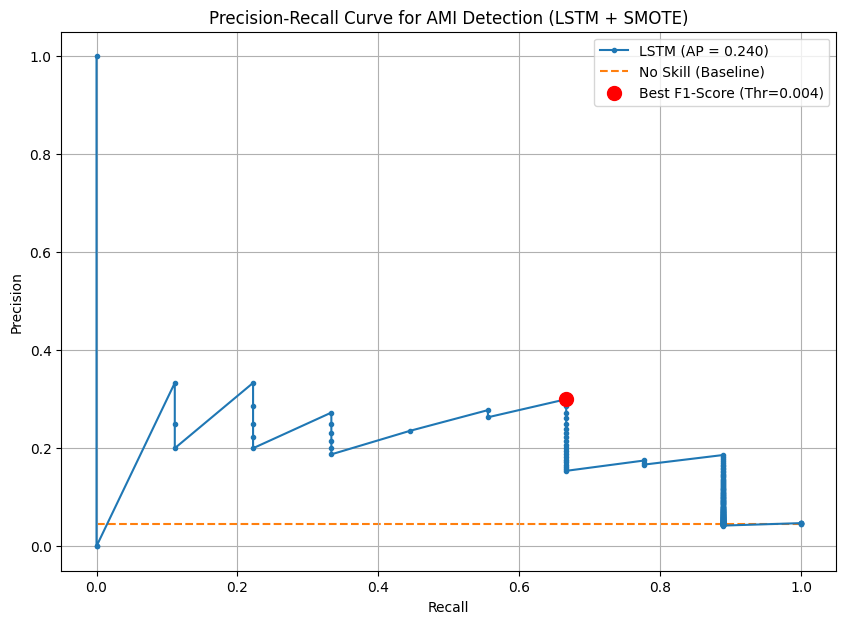

AUC: 0.8193701723113488
Accuracy (thr=0.5): 0.9183673469387755

Reports at different thresholds:

Threshold 0.5000
              precision    recall  f1-score   support

 Non-AMI (0)       0.97      0.95      0.96       187
     AMI (1)       0.23      0.33      0.27         9

    accuracy                           0.92       196
   macro avg       0.60      0.64      0.61       196
weighted avg       0.93      0.92      0.93       196


Threshold 0.4000
              precision    recall  f1-score   support

 Non-AMI (0)       0.97      0.95      0.96       187
     AMI (1)       0.23      0.33      0.27         9

    accuracy                           0.92       196
   macro avg       0.60      0.64      0.61       196
weighted avg       0.93      0.92      0.93       196


Threshold 0.3000
              precision    recall  f1-score   support

 Non-AMI (0)       0.97      0.95      0.96       187
     AMI (1)       0.23      0.33      0.27         9

    accuracy                   

In [ ]:
# --- Plot Precision-Recall Curve ---
print("\n--- Plotting Precision-Recall Curve ---")

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, preds)

# Calculate Average Precision (AP), which is the area under the PR curve
ap = average_precision_score(y_test, preds)
print(f"Average Precision (AP / AUC-PR): {ap:.4f}")

# Calculate F1-score for all thresholds
# We add + 1e-9 to avoid division by zero
# We use [:-1] to align with the 'thresholds' array size
f1_scores = (2 * recall[:-1] * precision[:-1]) / (recall[:-1] + precision[:-1] + 1e-9)

# Find the threshold that gives the max F1
ix = np.argmax(f1_scores)
best_threshold = thresholds[ix]
print(f"Best Threshold (by F1-score): {best_threshold:.4f}")
print(f"  > F1: {f1_scores[ix]:.4f}")
print(f"  > Precision: {precision[ix]:.4f}")
print(f"  > Recall: {recall[ix]:.4f}")

# Plot the PR curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, marker='.', label=f'LSTM (AP = {ap:.3f})', zorder=2)

# Plot the "no skill" line (random classifier)
no_skill = (y_test == 1).sum() / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill (Baseline)', zorder=1)

# Plot the optimal F1 point
plt.scatter(recall[ix], precision[ix], marker='o', color='red', s=100,
            label=f'Best F1-Score (Thr={best_threshold:.3f})', zorder=3)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for AMI Detection (LSTM + SMOTE)')
plt.legend()
plt.grid(True)
plt.show()

# --- Continue with existing evaluation ---
print('AUC:', roc_auc_score(y_test, preds))
print('Accuracy (thr=0.5):', accuracy_score(y_test, (preds>0.5).astype(int)))

# --- Now, add the "best" threshold to your loop ---
print("\nReports at different thresholds:")
all_thresholds_to_check = sorted(list(set([0.5, 0.4, 0.3, 0.2] + [best_threshold])), reverse=True)

for thr in all_thresholds_to_check:
    print(f"\nThreshold {thr:.4f}" + (" (Best F1)" if thr == best_threshold else ""))
    y_pred_thr = (preds > thr).astype(int)
    print(classification_report(y_test, y_pred_thr, target_names=["Non-AMI (0)", "AMI (1)"]))

# --- Your original threshold loop (you can replace it with the one above) ---
# print("\nReports at different thresholds:")
# for thr in [0.5,0.4,0.3,0.2]:
#     print(f"\nThreshold {thr}")
#     y_pred_thr = (preds>thr).astype(int)
#     print(classification_report(y_test,y_pred_thr, target_names=["Non-AMI (0)", "AMI (1)"]))

In [ ]:
!pip install xgboost

## ***[XGBOOST MODEL APPLIED ON OUR DATASET ](https://)***

In [ ]:
# Final XGBoost pipeline — Colab-ready
# - Robust xgboost import (auto-install)
# - XGBoost 3.x-compatible training (eval_metric in constructor, callbacks for early stopping)
# - Time-aware feature engineering from /content/relevant_labs.csv
# - Saves model + scaler/features to /content

import warnings, os, pickle, sys, subprocess, traceback
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.linear_model import LinearRegression

# ---------- Paths (Colab) ----------
LABS_CSV = "/content/relevant_labs.csv"
DIAG_CSV = "/content/diagnoses_icd.csv"
MODEL_OUT = "/content/xgb_ami_model_fromscratch.pkl"
SCALER_OUT = "/content/xgb_scaler_and_features_fromscratch.pkl"

# ---------- Preferred biomarkers (will fallback to top-by-presence if not found) ----------
PREFERRED_BIOMARKERS = [
    "hs-cTn I","CK-MB","CRP","IL-6","TNF-α",
    "MPO","PTX-3","suPAR","NGAL","NLR","MPV","PLR"
]

# ---------- Helper functions ----------
def detect_ami_codes(s):
    if pd.isna(s):
        return False
    s = str(s).upper()
    if s.startswith("410") or s.startswith("I21"):
        return True
    if "AMI" in s or "ACUTE MYOCARDIAL" in s or "MYOCARDIAL INFARCTION" in s:
        return True
    return False

def slope_of_series(times, values):
    mask = ~np.isnan(values)
    if mask.sum() < 2:
        return np.nan
    X = times[mask].reshape(-1,1)
    y = values[mask]
    lr = LinearRegression()
    lr.fit(X,y)
    return float(lr.coef_[0])

def find_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    for c in cols:
        if c.lower() in [x.lower() for x in candidates]:
            return c
    return None

# ---------- Robust xgboost import/install ----------
def ensure_xgboost_installed(install_if_missing=True):
    try:
        import xgboost as xgb
        print("xgboost import OK — version:", getattr(xgb, "__version__", "unknown"))
        return xgb
    except Exception as first_err:
        print("Initial import of xgboost failed:", str(first_err))
        if not install_if_missing:
            raise
        print("Attempting to install/upgrade xgboost into the current interpreter...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "xgboost"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            import importlib
            xgb = importlib.import_module("xgboost")
            print("xgboost imported after install — version:", getattr(xgb, "__version__", "unknown"))
            return xgb
        except Exception as second_err:
            print("xgboost import failed even after attempting installation.")
            print("=== First import exception ===")
            traceback.print_exception(type(first_err), first_err, first_err.__traceback__)
            print("\n=== Second import/install exception ===")
            traceback.print_exception(type(second_err), second_err, second_err.__traceback__)
            raise RuntimeError("xgboost import/install failed. Try restarting the runtime and re-running the notebook. See tracebacks above.") from second_err

xgb = ensure_xgboost_installed(install_if_missing=True)

# ---------- Load and normalize input CSVs ----------
print("Reading labs CSV (may take a moment)...")
sample = pd.read_csv(LABS_CSV, nrows=200)
cols = sample.columns.tolist()

patient_col = find_col(cols, ["subject_id","patient_id","hadm_id"])
time_col = find_col(cols, ["charttime","time","datetime","date"])
itemid_col = find_col(cols, ["itemid","label","lab_name","test_name","component"])
value_col = find_col(cols, ["valuenum","value_num","value","result","lab_value"])
ref_low_col = find_col(cols, ["ref_range_lower","ref_low","low"])
ref_high_col = find_col(cols, ["ref_range_upper","ref_high","high"])
flag_col = find_col(cols, ["flag","abnormal"])

usecols = [c for c in [patient_col, time_col, itemid_col, value_col, ref_low_col, ref_high_col, flag_col] if c is not None]
labs = pd.read_csv(LABS_CSV, usecols=usecols, parse_dates=[time_col] if time_col else None)

# Rename consistent columns
labs = labs.rename(columns={patient_col:"subject_id", time_col:"charttime", itemid_col:"label", value_col:"valuenum"})
if ref_low_col: labs = labs.rename(columns={ref_low_col:"ref_low"})
if ref_high_col: labs = labs.rename(columns={ref_high_col:"ref_high"})
if flag_col: labs = labs.rename(columns={flag_col:"flag"})

labs["valuenum"] = pd.to_numeric(labs["valuenum"], errors="coerce")
labs["charttime"] = pd.to_datetime(labs["charttime"], errors="coerce")

# Load diagnoses and detect AMI patients
diags = pd.read_csv(DIAG_CSV)
diag_patient = find_col(diags.columns.tolist(), ["subject_id","patient_id","hadm_id"])
diag_code = find_col(diags.columns.tolist(), ["icd_code","code","diagnosis"])
if diag_patient is None or diag_code is None:
    diag_patient = diag_patient or diags.columns[0]
    diag_code = diag_code or diags.columns[1] if len(diags.columns)>1 else diags.columns[0]
diags = diags.rename(columns={diag_patient:"subject_id", diag_code:"icd_code"})
diags["is_ami"] = diags["icd_code"].apply(detect_ami_codes)
ami_patients = set(diags.loc[diags["is_ami"], "subject_id"].unique())

# ---------- Choose biomarkers (preferred or top-by-presence) ----------
available = labs["label"].dropna().unique().tolist()
use_biomarkers = []
for b in PREFERRED_BIOMARKERS:
    for a in available:
        if str(a).strip().lower() == str(b).strip().lower():
            use_biomarkers.append(a)
            break

if len(use_biomarkers) == 0:
    print("Preferred biomarkers not found. Selecting top 20 by presence.")
    last_vals = labs.sort_values(["subject_id","charttime"]).groupby(["subject_id","label"])["valuenum"].last().reset_index()
    pivot = last_vals.pivot(index="subject_id", columns="label", values="valuenum")
    top = pivot.notna().sum().sort_values(ascending=False).index[:20].tolist()
    use_biomarkers = top
print("Using biomarkers:", use_biomarkers)

# ---------- Feature engineering (time-aware) ----------
print("Starting feature engineering (this may take several minutes on large files)...")
global_max_time = labs["charttime"].max()
rows = []
subjects = []
grouped = labs.groupby("subject_id")

for i, (pid, g) in enumerate(grouped):
    if i % 500 == 0 and i > 0:
        print(f"Processed {i} patients...")
    subjects.append(pid)
    feat = {}
    g = g.sort_values("charttime")
    feat["num_tests_total"] = len(g)
    feat["num_distinct_tests"] = g["label"].nunique()
    if g["charttime"].notna().sum() >= 2:
        feat["overall_time_span_hours"] = (g["charttime"].max() - g["charttime"].min()).total_seconds()/3600.0
    else:
        feat["overall_time_span_hours"] = 0.0

    for biom in use_biomarkers:
        sub = g[g["label"]==biom].dropna(subset=["charttime"])
        vals = sub["valuenum"].values.astype(float) if len(sub)>0 else np.array([])
        times = sub["charttime"].astype('datetime64[ns]').astype('int64') // 10**9 if len(sub)>0 else np.array([])
        times_h = (times - times.min())/3600.0 if len(times)>0 else np.array([])
        pfx = str(biom).replace(" ","_").replace("/","_").replace("-","_")
        feat[f"{pfx}__count"] = len(vals)
        feat[f"{pfx}__last_value"] = float(vals[-1]) if len(vals)>0 else np.nan
        feat[f"{pfx}__mean"] = float(np.nanmean(vals)) if len(vals)>0 else np.nan
        feat[f"{pfx}__std"] = float(np.nanstd(vals)) if len(vals)>0 else np.nan
        feat[f"{pfx}__min"] = float(np.nanmin(vals)) if len(vals)>0 else np.nan
        feat[f"{pfx}__max"] = float(np.nanmax(vals)) if len(vals)>0 else np.nan
        feat[f"{pfx}__median"] = float(np.nanmedian(vals)) if len(vals)>0 else np.nan
        if len(sub)>0:
            last_time = sub["charttime"].max()
            feat[f"{pfx}__last_time_recency_hours"] = (global_max_time - last_time).total_seconds()/3600.0
            feat[f"{pfx}__time_span_hours"] = (sub["charttime"].max() - sub["charttime"].min()).total_seconds()/3600.0 if sub["charttime"].notna().sum()>1 else 0.0
        else:
            feat[f"{pfx}__last_time_recency_hours"] = np.nan
            feat[f"{pfx}__time_span_hours"] = np.nan
        feat[f"{pfx}__slope_per_hour"] = slope_of_series(np.array(times_h), np.array(vals)) if len(vals)>1 else np.nan
        try:
            feat[f"{pfx}__ewma"] = float(pd.Series(vals).ewm(span=3, adjust=False).mean().iloc[-1]) if len(vals)>0 else np.nan
        except:
            feat[f"{pfx}__ewma"] = np.nan
        if "ref_low" in sub.columns and "ref_high" in sub.columns:
            valid = (~sub["ref_low"].isna()) & (~sub["ref_high"].isna()) & (~sub["valuenum"].isna())
            if valid.sum()>0:
                is_ab = ((sub.loc[valid,"valuenum"] < sub.loc[valid,"ref_low"]) | (sub.loc[valid,"valuenum"] > sub.loc[valid,"ref_high"])).sum()/float(valid.sum())
                feat[f"{pfx}__fraction_abnormal"] = float(is_ab)
            else:
                feat[f"{pfx}__fraction_abnormal"] = np.nan
        else:
            feat[f"{pfx}__fraction_abnormal"] = np.nan

    rows.append(feat)

# ---------- Build DataFrame ----------
X = pd.DataFrame(rows, index=subjects).reset_index().rename(columns={"index":"subject_id"})
for c in X.columns:
    if X[c].dtype == object:
        X[c] = pd.to_numeric(X[c], errors='coerce')
X = X.fillna(X.median())
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
y = X["subject_id"].apply(lambda s: 1 if s in ami_patients else 0).values

print("Final feature matrix:", X[num_cols].shape, "Positive rate:", y.mean())

# ---------- Train/test split + scale ----------
X_train, X_test, y_train, y_test = train_test_split(X[num_cols].values, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_pos, n_neg = (y_train==1).sum(), (y_train==0).sum()
scale_pos_weight = n_neg / max(1, n_pos)
print("Class balance:", n_pos, "AMI vs", n_neg, "non-AMI, scale_pos_weight =", scale_pos_weight)

# ---------- Train XGBoost (XGBoost 3.x-compatible) ----------
print("Training XGBoost model now...")

# Use callback-based early stopping
# ***FIX: Define the callback *before* initializing the classifier***
early_stop = xgb.callback.EarlyStopping(rounds=20, save_best=True)

clf = xgb.XGBClassifier(
    n_estimators=300,
    random_state=42,
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    n_jobs=4,
    eval_metric="auc",         # set in constructor
    callbacks=[early_stop]   # ***FIX: Pass callbacks to the constructor***
)

# ***FIX: Remove 'callbacks' from the .fit() method***
clf.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=True
)

model = clf
model_name = "xgboost"

# ---------- Evaluate ----------
probs = model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test, probs)
print(f"\nModel: {model_name}  |  AUC: {auc:.4f}")
print("Accuracy (thr=0.5):", accuracy_score(y_test, (probs>0.5).astype(int)))

for thr in [0.5, 0.4, 0.3, 0.2]:
    print(f"\n--- Threshold {thr} ---")
    print(classification_report(y_test, (probs>thr).astype(int), digits=4))

# ---------- Save artifacts ----------
with open(MODEL_OUT, "wb") as f:
    pickle.dump(model, f)
with open(SCALER_OUT, "wb") as f:
    pickle.dump({"scaler":scaler, "feature_names":num_cols, "used_biomarkers":use_biomarkers}, f)

print("\nSaved model to:", MODEL_OUT)
print("Saved scaler/features to:", SCALER_OUT)

xgboost import OK — version: 3.1.1
Reading labs CSV (may take a moment)...
Preferred biomarkers not found. Selecting top 20 by presence.
Using biomarkers: [51221, 51222, 51301, 51248, 51250, 51249, 51279, 51277, 51265, 50912, 50931, 50971, 50983, 50902, 50882, 51146, 51244, 51200, 51256, 51254]
Starting feature engineering (this may take several minutes on large files)...
Processed 500 patients...
Processed 1000 patients...
Processed 1500 patients...
Processed 2000 patients...
Processed 2500 patients...
Processed 3000 patients...
Processed 3500 patients...
Final feature matrix: (3991, 244) Positive rate: 0.03983963918817339
Class balance: 127 AMI vs 3065 non-AMI, scale_pos_weight = 24.133858267716537
Training XGBoost model now...
[0]	validation_0-auc:0.83640
[1]	validation_0-auc:0.80574
[2]	validation_0-auc:0.84485
[3]	validation_0-auc:0.83682
[4]	validation_0-auc:0.82782
[5]	validation_0-auc:0.81551
[6]	validation_0-auc:0.84053
[7]	validation_0-auc:0.83837
[8]	validation_0-auc:0.83360

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, auc


--- Plotting Precision-Recall Curve ---
Average Precision (AP / AUC-PR): 0.2061
Best Threshold (by F1-score): 0.3868
  > F1: 0.2895
  > Precision: 0.2500
  > Recall: 0.3438


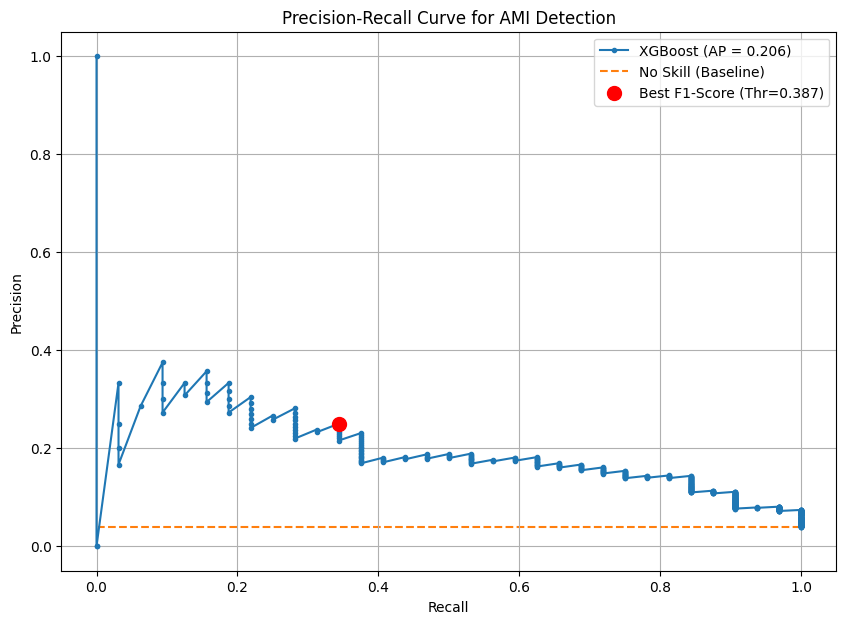


--- Classification Report at Best F1 Threshold (0.3868) ---
              precision    recall  f1-score   support

           0     0.9709    0.9570    0.9639       767
           1     0.2326    0.3125    0.2667        32

    accuracy                         0.9312       799
   macro avg     0.6017    0.6347    0.6153       799
weighted avg     0.9413    0.9312    0.9360       799



In [ ]:
# ---------- Plot Precision-Recall Curve ----------

print("\n--- Plotting Precision-Recall Curve ---")

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Calculate Average Precision (AP), which is the area under the PR curve
ap = average_precision_score(y_test, probs)
print(f"Average Precision (AP / AUC-PR): {ap:.4f}")

# Calculate F1-score for all thresholds
# We add + 1e-9 to avoid division by zero
# We use [:-1] to align with the 'thresholds' array size
f1_scores = (2 * recall[:-1] * precision[:-1]) / (recall[:-1] + precision[:-1] + 1e-9)

# Find the threshold that gives the max F1
ix = np.argmax(f1_scores)
best_threshold = thresholds[ix]
print(f"Best Threshold (by F1-score): {best_threshold:.4f}")
print(f"  > F1: {f1_scores[ix]:.4f}")
print(f"  > Precision: {precision[ix]:.4f}")
print(f"  > Recall: {recall[ix]:.4f}")

# Plot the PR curve
plt.figure(figsize=(10, 7))
plt.plot(recall, precision, marker='.', label=f'XGBoost (AP = {ap:.3f})', zorder=2)

# Plot the "no skill" line (random classifier)
no_skill = (y_test == 1).sum() / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill (Baseline)', zorder=1)

# Plot the optimal F1 point
plt.scatter(recall[ix], precision[ix], marker='o', color='red', s=100,
            label=f'Best F1-Score (Thr={best_threshold:.3f})', zorder=3)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for AMI Detection')
plt.legend()
plt.grid(True)
plt.show()

# --- Now, re-run classification report with the new best threshold ---
print(f"\n--- Classification Report at Best F1 Threshold ({best_threshold:.4f}) ---")
print(classification_report(y_test, (probs > best_threshold).astype(int), digits=4))

# EXTERNAL DATASET XGBOOST APPLIED ON IT

In [ ]:
import pandas as pd

EXCEL_FILE_PATH = "/content/dataset.xlsx"

print(f"--- Analyzing sheets and columns in {EXCEL_FILE_PATH} ---")
try:
    xls = pd.ExcelFile(EXCEL_FILE_PATH)
    print("\nSheets found:")
    for sheet_name in xls.sheet_names:
        print(f"  - {sheet_name}")
        # Read only a small portion to inspect columns without loading the whole sheet
        try:
            df_sheet = xls.parse(sheet_name, nrows=5) # Read first 5 rows to get columns
            print(f"    Columns in '{sheet_name}':")
            for col in df_sheet.columns:
                print(f"      - {col}")
            print(f"    --- End of columns for '{sheet_name}' ---")
        except Exception as e:
            print(f"    Could not read columns for sheet '{sheet_name}': {e}")

except FileNotFoundError:
    print(f"ERROR: File not found at {EXCEL_FILE_PATH}")
except Exception as e:
    print(f"An error occurred: {e}")

--- Analyzing sheets and columns in /content/dataset.xlsx ---

Sheets found:
  - Sayfa1
    Columns in 'Sayfa1':
      - group  (control:0, AMI:1)
      - sub-type for AMI( STEMI:0, NON-STEMI :1, control:2)
      - Age
      - Gender (0:female, 1:male)
      - WBC
      - RBC
      - HGB
      - BA
      - EO
      - LY
      - MO
      - NEU
      - NEU/LY
      - PLT/LY
      - MPV/LY
      - LY/MO
      - MPV
      - PLT
      - HCT
      - MCV
      - RDW-SD
      - RDW-CV
      - MCH
      - MCHC
      - PDW 
      - PCT
    --- End of columns for 'Sayfa1' ---


--- 1. Initial Data Load ---
   group  (control:0, AMI:1)  \
0                          0   
1                          0   
2                          0   
3                          0   
4                          0   

   sub-type for AMI( STEMI:0, NON-STEMI :1, control:2)  Age  \
0                                                  2     28   
1                                                  2     40   
2                                                  2     64   
3                                                  2     57   
4                                                  2     58   

   Gender (0:female, 1:male)    WBC   RBC   HGB    BA    EO    LY  ...    MPV  \
0                          1  10.90  5.09  15.3  0.06  0.19  2.77  ...  10.00   
1                          0   5.96  5.16  15.6  0.03  0.37  2.36  ...  13.30   
2                          1   4.59  5.51  14.9  0.05  0.05  1.12  ...  11.00   
3                          0   7.26  4.70  12.5  0.05  0.11  3.46  ...  10.

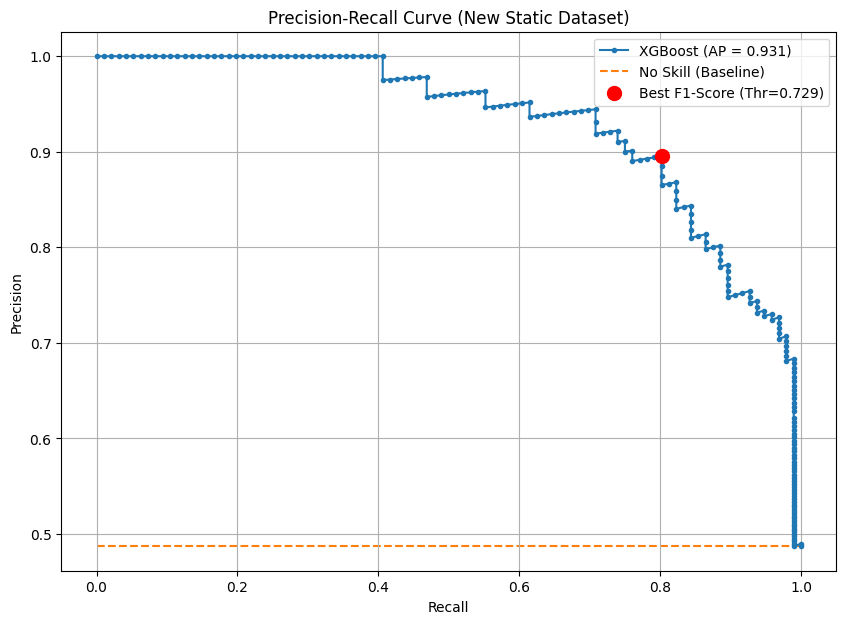


--- Classification Reports ---

--- Threshold 0.7293 (Best F1) ---
              precision    recall  f1-score   support

           0     0.8214    0.9109    0.8638       101
           1     0.8941    0.7917    0.8398        96

    accuracy                         0.8528       197
   macro avg     0.8578    0.8513    0.8518       197
weighted avg     0.8569    0.8528    0.8521       197


--- Threshold 0.5000 ---
              precision    recall  f1-score   support

           0     0.8431    0.8515    0.8473       101
           1     0.8421    0.8333    0.8377        96

    accuracy                         0.8426       197
   macro avg     0.8426    0.8424    0.8425       197
weighted avg     0.8426    0.8426    0.8426       197


--- Threshold 0.4000 ---
              precision    recall  f1-score   support

           0     0.8454    0.8119    0.8283       101
           1     0.8100    0.8438    0.8265        96

    accuracy                         0.8274       197
   macro

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, precision_recall_curve, average_precision_score
import warnings

warnings.filterwarnings('ignore')

# Define file path
FILE_PATH = "/content/dataset.xlsx" # Corrected to use the Excel file path

try:
    # Load the dataset
    df = pd.read_excel(FILE_PATH) # Changed to read_excel

    print("--- 1. Initial Data Load ---")
    print(df.head())
    print("\n--- 2. Cleaning Column Names ---")

    # Clean column names
    rename_map = {}
    for col in df.columns:
        if 'group' in col.lower():
            rename_map[col] = 'target'
        elif 'sub-type' in col.lower():
            rename_map[col] = 'sub_type'
        elif 'gender' in col.lower():
            rename_map[col] = 'Gender'
        else:
            # Remove spaces and special chars from other columns
            clean_name = col.replace(" ", "").replace("(", "").replace(")", "").replace("/", "_")
            rename_map[col] = clean_name

    df = df.rename(columns=rename_map)

    print("Cleaned column names:")
    print(df.columns.tolist())

    # --- 3. Define Features (X) and Target (y) ---

    # The target is the 'target' column
    y = df['target']

    # The features are all columns *except* 'target' and 'sub_type'
    # 'sub_type' is data leakage - it gives away the answer
    features_to_drop = ['target', 'sub_type']
    feature_names = [col for col in df.columns if col not in features_to_drop]
    X = df[feature_names]

    print(f"\nTarget column: 'target'")
    print(f"Features used ({len(feature_names)}): {feature_names}")

    # --- 4. Handle Missing Values ---
    print("\n--- 4. Handling Missing Values ---")
    print("Missing values BEFORE fill:")
    print(X.isnull().sum().loc[X.isnull().sum() > 0])

    # Create a copy to avoid SettingWithCopyWarning
    X_filled = X.copy()

    # Fill NaNs with the median of each column
    for col in X_filled.columns:
        if X_filled[col].isnull().any():
            # Only fill numeric columns
            if pd.api.types.is_numeric_dtype(X_filled[col]):
                median_val = X_filled[col].median()
                X_filled[col] = X_filled[col].fillna(median_val)
            else:
                # For non-numeric, maybe fill with mode or a placeholder
                # For now, leave non-numeric NaNs or handle specifically if needed
                print(f"Warning: Column '{col}' is not numeric and contains NaNs. Leaving NaNs for now.")


    print("\nMissing values AFTER fill (should be 0 for numeric cols):")
    print(X_filled.select_dtypes(include=np.number).isnull().sum().sum())


    # --- 5. Train/Test Split ---
    X_train, X_test, y_train, y_test = train_test_split(X_filled, y, test_size=0.2, stratify=y, random_state=42)

    print(f"\n--- 5. Data Split ---")
    print(f"Training set: {X_train.shape}, {y_train.shape}")
    print(f"Test set: {X_test.shape}, {y_test.shape}")

    # --- 6. Scale Data ---
    # Only scale numeric features
    numeric_cols_train = X_train.select_dtypes(include=np.number).columns.tolist()
    numeric_cols_test = X_test.select_dtypes(include=np.number).columns.tolist()

    scaler = StandardScaler()
    X_train_scaled = X_train.copy() # Copy to avoid modifying original
    X_test_scaled = X_test.copy()

    X_train_scaled[numeric_cols_train] = scaler.fit_transform(X_train_scaled[numeric_cols_train])
    X_test_scaled[numeric_cols_test] = scaler.transform(X_test_scaled[numeric_cols_test])


    print("\n--- 6. Data Scaled (Numeric Features Only) ---")

    # --- 7. Handle Class Imbalance ---
    n_pos, n_neg = (y_train==1).sum(), (y_train==0).sum()
    scale_pos_weight = n_neg / max(1, n_pos)

    print(f"\n--- 7. Class Balance ---")
    print(f"Training data: {n_pos} AMI (1) vs {n_neg} Control (0)")
    print(f"Calculated 'scale_pos_weight': {scale_pos_weight:.2f}")

    # --- 8. Train XGBoost Model ---
    print("\n--- 8. Training XGBoost Model ---")

    # Use callback-based early stopping
    early_stop = xgb.callback.EarlyStopping(rounds=20, save_best=True)

    clf = xgb.XGBClassifier(
        n_estimators=300,
        random_state=42,
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,  # Use the calculated weight
        n_jobs=-1,
        eval_metric="auc",         # set in constructor
        callbacks=[early_stop]   # Pass callbacks to the constructor
    )

    # XGBoost requires numeric input
    clf.fit(
        X_train_scaled.select_dtypes(include=np.number),
        y_train,
        eval_set=[(X_test_scaled.select_dtypes(include=np.number), y_test)],
        verbose=False # Set to True if you want to see training progress
    )

    print("Model training complete.")

    # --- 9. Evaluate Model ---
    print("\n--- 9. Model Evaluation on Test Set ---")

    # Get probabilities (use numeric features for prediction)
    probs = clf.predict_proba(X_test_scaled.select_dtypes(include=np.number))[:,1]

    # Calculate ROC AUC
    auc = roc_auc_score(y_test, probs)
    print(f"ROC AUC: {auc:.4f}")

    # --- Plot Precision-Recall Curve ---
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)

    # Handle edge case where f1_scores might be empty
    f1_scores = (2 * recall[:-1] * precision[:-1]) / (recall[:-1] + precision[:-1] + 1e-9)
    if len(f1_scores) > 0:
        ix = np.argmax(f1_scores)
        best_threshold = thresholds[ix]
        print(f"Average Precision (AP / AUC-PR): {ap:.4f}")
        print(f"Best Threshold (by F1-score): {best_threshold:.4f}")

        plt.figure(figsize=(10, 7))
        plt.plot(recall, precision, marker='.', label=f'XGBoost (AP = {ap:.3f})', zorder=2)
        no_skill = (y_test == 1).sum() / len(y_test)
        plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill (Baseline)', zorder=1)
        plt.scatter(recall[ix], precision[ix], marker='o', color='red', s=100,
                    label=f'Best F1-Score (Thr={best_threshold:.3f})', zorder=3)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve (New Static Dataset)')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        best_threshold = 0.5 # Fallback
        print("Could not plot PR Curve (not enough data points).")
        print(f"Average Precision (AP / AUC-PR): {ap:.4f}")


    # --- Classification Reports ---
    print("\n--- Classification Reports ---")
    all_thresholds_to_check = sorted(list(set([0.5, 0.4] + [best_threshold])), reverse=True)

    for thr in all_thresholds_to_check:
        print(f"\n--- Threshold {thr:.4f}" + (" (Best F1)" if thr == best_threshold else "") + " ---")
        print(classification_report(y_test, (probs > thr).astype(int), digits=4))

except FileNotFoundError:
    print(f"ERROR: File not found at {FILE_PATH}")
    print("Please make sure 'dataset.xlsx' is uploaded.")
except ImportError:
    print("\n--- IMPORT ERROR ---")
    print("XGBoost library not found. Please run 'pip install xgboost' in a code cell and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

### ***XGBOOST*** ***static***


In [ ]:
#!/usr/bin/env python3
"""
Static XGBoost Model for AMI Prediction using Biomarkers
--------------------------------------------------------
- Reads /content/relevant_labs.csv (lab results)
- Aggregates mean biomarker value per patient (static features)
- Uses preferred biomarkers if available, else top 20 via RandomForest
- Merges /content/diagnoses_icd.csv for AMI labels
- Trains XGBoost with imbalance handling
- Prints AUC, accuracy, classification report at thresholds [0.5, 0.4, 0.3, 0.2]
- Saves model, scaler, and features list
"""

import os
import pandas as pd
import numpy as np
import pickle
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from xgboost import XGBClassifier

# ---------------- PATHS ----------------
LABS_FILE = "/content/relevant_labs.csv"
DIAG_FILE = "/content/diagnoses_icd.csv"
OUT_DIR = "/content"
CHUNKSIZE = 200000

# ---------------- CONFIG ----------------
PREFERRED_BIOMARKERS = [
    "hs-cTn I", "CK-MB", "CRP", "IL-6", "TNF-α",
    "MPO", "PTX-3", "suPAR", "NGAL", "NLR", "MPV", "PLR"
]
THRESHOLDS = [0.5, 0.4, 0.3, 0.2]

# ---------------- HELPERS ----------------
def detect_ami_codes(s):
    if pd.isna(s):
        return False
    s = str(s).upper()
    if s.startswith("410") or s.startswith("I21"):
        return True
    if "AMI" in s or "MYOCARDIAL INFARCTION" in s:
        return True
    return False

def pick_col(cols, candidates):
    cols_lower = [c.lower() for c in cols]
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols[cols_lower.index(cand.lower())]
    return None

# ---------------- PIPELINE ----------------
def build_static_xgb():
    os.makedirs(OUT_DIR, exist_ok=True)

    # Step 1: detect key columns
    sample = pd.read_csv(LABS_FILE, nrows=5000, low_memory=False)
    pcol = pick_col(sample.columns, ["subject_id", "patient_id", "hadm_id"])
    labcol = pick_col(sample.columns, ["label", "lab_name", "test_name", "component", "itemid"])
    valcol = pick_col(sample.columns, ["valuenum", "value", "result", "value_num", "test_value"])
    if not (pcol and labcol and valcol):
        raise ValueError(f"Column detection failed. Found columns: {sample.columns.tolist()}")
    print(f"[Detected columns] patient: {pcol} | lab: {labcol} | value: {valcol}")

    # Step 2: chunked aggregation
    agg = defaultdict(lambda: [0.0, 0])
    reader = pd.read_csv(LABS_FILE, chunksize=CHUNKSIZE, low_memory=True)
    for i, chunk in enumerate(reader, 1):
        df = chunk[[pcol, labcol, valcol]].rename(columns={pcol: "patient_id", labcol: "lab_name", valcol: "value"})
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna(subset=["patient_id", "lab_name"])
        grp = df.groupby(["patient_id", "lab_name"])["value"].agg(["sum", "count"]).reset_index()
        for _, r in grp.iterrows():
            key = (r["patient_id"], r["lab_name"])
            agg[key][0] += float(r["sum"])
            agg[key][1] += int(r["count"])
        if i % 5 == 0:
            print(f"  processed {i} chunks...")

    print(f"[Aggregation done] Unique patient-lab pairs: {len(agg):,}")

    # Step 3: per-patient means
    rows = [(pid, lab, s / c if c > 0 else np.nan) for (pid, lab), (s, c) in agg.items()]
    feat_df = pd.DataFrame(rows, columns=["patient_id", "lab_name", "mean_value"])
    pivot = feat_df.pivot(index="patient_id", columns="lab_name", values="mean_value")
    pivot_filled = pivot.fillna(pivot.median())
    features_file = os.path.join(OUT_DIR, "patient_static_features.parquet")
    pivot_filled.reset_index().to_parquet(features_file)
    print(f"[Saved static features] {features_file}")

    # Step 4: load diagnoses for AMI labels
    if not os.path.exists(DIAG_FILE):
        print("No diagnoses file found, skipping model training.")
        return

    diags = pd.read_csv(DIAG_FILE, low_memory=False)
    pcol_diag = pick_col(diags.columns, ["subject_id", "patient_id", "hadm_id"])
    codecol = pick_col(diags.columns, ["icd_code", "code", "diagnosis", "icd9_code"])
    if pcol_diag is None or codecol is None:
        print("diagnoses_icd.csv column detection failed, skipping training.")
        return

    diags = diags.rename(columns={pcol_diag: "patient_id", codecol: "icd_code"})
    diags["is_ami"] = diags["icd_code"].apply(detect_ami_codes)
    ami_patients = set(diags.loc[diags["is_ami"], "patient_id"].unique())
    pivot_filled["is_ami"] = pivot_filled.index.to_series().apply(lambda pid: 1 if pid in ami_patients else 0).values
    print(f"[Labels created] Positive cases: {pivot_filled['is_ami'].sum()} / {pivot_filled.shape[0]}")

    # Step 5: select biomarkers
    available = list(pivot_filled.columns)
    used_biomarkers = [b for b in PREFERRED_BIOMARKERS if b in available]
    if len(used_biomarkers) == 0:
        print("Preferred biomarkers not found, using top 20 by RandomForest importance.")
        rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        X_tmp = pivot_filled.drop(columns=["is_ami"]).fillna(0).values
        y_tmp = pivot_filled["is_ami"].astype(int).values
        rf.fit(X_tmp, y_tmp)
        idx = np.argsort(rf.feature_importances_)[::-1][:20]
        used_biomarkers = [pivot_filled.columns[i] for i in idx]
        print(f"Top 20 biomarkers: {used_biomarkers}")
    else:
        print(f"Using preferred biomarkers: {used_biomarkers}")

    # Step 6: prepare data
    X = pivot_filled[used_biomarkers].values
    y = pivot_filled["is_ami"].astype(int).values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Step 7: train XGBoost
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1.0
    model = XGBClassifier(
        n_estimators=300,
        eval_metric="logloss",
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_test)[:, 1]

    # Step 8: evaluate
    print(f"\nAUC: {roc_auc_score(y_test, preds):.4f}")
    print(f"Accuracy (thr=0.5): {accuracy_score(y_test, (preds > 0.5).astype(int)):.4f}")
    for thr in THRESHOLDS:
        print(f"\n--- Threshold {thr} ---")
        print(classification_report(y_test, (preds > thr).astype(int), digits=4))

    # Step 9: save model and scaler
    out_path = os.path.join(OUT_DIR, "xgb_static_ami_model.pkl")
    with open(out_path, "wb") as f:
        pickle.dump({"model": model, "scaler": scaler, "features": used_biomarkers}, f)
    print(f"[Model saved] {out_path}")

# ---------------- RUN ----------------
if __name__ == "__main__":
    build_static_xgb()


[Detected columns] patient: subject_id | lab: label | value: valuenum
  processed 5 chunks...
[Aggregation done] Unique patient-lab pairs: 121,987
[Saved static features] /content/patient_static_features.parquet


/tmp/ipython-input-1701643240.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pivot_filled["is_ami"] = pivot_filled.index.to_series().apply(lambda pid: 1 if pid in ami_patients else 0).values


[Labels created] Positive cases: 159 / 3991
Preferred biomarkers not found, using top 20 by RandomForest importance.
Top 20 biomarkers: ['Troponin T', 'Creatine Kinase, MB Isoenzyme', 'CK-MB Index', 'Creatine Kinase (CK)', 'Creatinine', 'NTproBNP', '% Hemoglobin A1c', 'Hematocrit, Calculated', 'Hemoglobin', 'Lactate Dehydrogenase (LD)', 'Cholesterol, Total', 'Alkaline Phosphatase', 'Potassium', 'Bicarbonate', 'White Blood Cells', 'Glucose', 'Red Blood Cells', 'RDW', 'Hematocrit', 'Neutrophils']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:17:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



AUC: 0.9452
Accuracy (thr=0.5): 0.9675

--- Threshold 0.5 ---
              precision    recall  f1-score   support

           0     0.9818    0.9844    0.9831       767
           1     0.6000    0.5625    0.5806        32

    accuracy                         0.9675       799
   macro avg     0.7909    0.7734    0.7819       799
weighted avg     0.9665    0.9675    0.9670       799


--- Threshold 0.4 ---
              precision    recall  f1-score   support

           0     0.9817    0.9817    0.9817       767
           1     0.5625    0.5625    0.5625        32

    accuracy                         0.9650       799
   macro avg     0.7721    0.7721    0.7721       799
weighted avg     0.9650    0.9650    0.9650       799


--- Threshold 0.3 ---
              precision    recall  f1-score   support

           0     0.9830    0.9804    0.9817       767
           1     0.5588    0.5938    0.5758        32

    accuracy                         0.9650       799
   macro avg     0.

In [ ]:
#!/usr/bin/env python3
"""
Static XGBoost Model for AMI Prediction using Biomarkers + PR curve

- Same pipeline as before (aggregate per-patient means, train XGBoost)
- After evaluation, computes Precision-Recall curve and Average Precision (AP)
- Saves PR curve to OUT_DIR/pr_curve.png
"""

import os
import pandas as pd
import numpy as np
import pickle
from collections import defaultdict
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    precision_recall_curve,
    average_precision_score,
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ---------------- PATHS ----------------
LABS_FILE = "/content/relevant_labs.csv"
DIAG_FILE = "/content/diagnoses_icd.csv"
OUT_DIR = "/content"
CHUNKSIZE = 200000

# ---------------- CONFIG ----------------
PREFERRED_BIOMARKERS = [
    "hs-cTn I", "CK-MB", "CRP", "IL-6", "TNF-α",
    "MPO", "PTX-3", "suPAR", "NGAL", "NLR", "MPV", "PLR"
]
THRESHOLDS = [0.5, 0.4, 0.3, 0.2]

# ---------------- HELPERS ----------------
def detect_ami_codes(s):
    if pd.isna(s):
        return False
    s = str(s).upper()
    if s.startswith("410") or s.startswith("I21"):
        return True
    if "AMI" in s or "MYOCARDIAL INFARCTION" in s:
        return True
    return False

def pick_col(cols, candidates):
    cols_lower = [c.lower() for c in cols]
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols[cols_lower.index(cand.lower())]
    return None

# ---------------- PIPELINE ----------------
def build_static_xgb_with_pr():
    os.makedirs(OUT_DIR, exist_ok=True)

    # Step 1: detect key columns
    sample = pd.read_csv(LABS_FILE, nrows=5000, low_memory=False)
    pcol = pick_col(sample.columns, ["subject_id", "patient_id", "hadm_id"])
    labcol = pick_col(sample.columns, ["label", "lab_name", "test_name", "component", "itemid"])
    valcol = pick_col(sample.columns, ["valuenum", "value", "result", "value_num", "test_value"])
    if not (pcol and labcol and valcol):
        raise ValueError(f"Column detection failed. Found columns: {sample.columns.tolist()}")
    print(f"[Detected columns] patient: {pcol} | lab: {labcol} | value: {valcol}")

    # Step 2: chunked aggregation
    agg = defaultdict(lambda: [0.0, 0])
    reader = pd.read_csv(LABS_FILE, chunksize=CHUNKSIZE, low_memory=True)
    for i, chunk in enumerate(reader, 1):
        df = chunk[[pcol, labcol, valcol]].rename(columns={pcol: "patient_id", labcol: "lab_name", valcol: "value"})
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna(subset=["patient_id", "lab_name"])
        grp = df.groupby(["patient_id", "lab_name"])["value"].agg(["sum", "count"]).reset_index()
        for _, r in grp.iterrows():
            key = (r["patient_id"], r["lab_name"])
            agg[key][0] += float(r["sum"])
            agg[key][1] += int(r["count"])
        if i % 5 == 0:
            print(f"  processed {i} chunks...")

    print(f"[Aggregation done] Unique patient-lab pairs: {len(agg):,}")

    # Step 3: per-patient means
    rows = [(pid, lab, s / c if c > 0 else np.nan) for (pid, lab), (s, c) in agg.items()]
    feat_df = pd.DataFrame(rows, columns=["patient_id", "lab_name", "mean_value"])
    pivot = feat_df.pivot(index="patient_id", columns="lab_name", values="mean_value")
    pivot_filled = pivot.fillna(pivot.median())
    features_file = os.path.join(OUT_DIR, "patient_static_features.parquet")
    pivot_filled.reset_index().to_parquet(features_file)
    print(f"[Saved static features] {features_file}")

    # Step 4: load diagnoses for AMI labels
    if not os.path.exists(DIAG_FILE):
        print("No diagnoses file found, skipping model training.")
        return

    diags = pd.read_csv(DIAG_FILE, low_memory=False)
    pcol_diag = pick_col(diags.columns, ["subject_id", "patient_id", "hadm_id"])
    codecol = pick_col(diags.columns, ["icd_code", "code", "diagnosis", "icd9_code"])
    if pcol_diag is None or codecol is None:
        print("diagnoses_icd.csv column detection failed, skipping training.")
        return

    diags = diags.rename(columns={pcol_diag: "patient_id", codecol: "icd_code"})
    diags["is_ami"] = diags["icd_code"].apply(detect_ami_codes)
    ami_patients = set(diags.loc[diags["is_ami"], "patient_id"].unique())
    pivot_filled["is_ami"] = pivot_filled.index.to_series().apply(lambda pid: 1 if pid in ami_patients else 0).values
    print(f"[Labels created] Positive cases: {pivot_filled['is_ami'].sum()} / {pivot_filled.shape[0]}")

    # Step 5: select biomarkers
    available = list(pivot_filled.columns)
    used_biomarkers = [b for b in PREFERRED_BIOMARKERS if b in available]
    if len(used_biomarkers) == 0:
        print("Preferred biomarkers not found, using top 20 by RandomForest importance.")
        rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        X_tmp = pivot_filled.drop(columns=["is_ami"]).fillna(0).values
        y_tmp = pivot_filled["is_ami"].astype(int).values
        rf.fit(X_tmp, y_tmp)
        idx = np.argsort(rf.feature_importances_)[::-1][:20]
        used_biomarkers = [pivot_filled.columns[i] for i in idx]
        print(f"Top 20 biomarkers: {used_biomarkers}")
    else:
        print(f"Using preferred biomarkers: {used_biomarkers}")

    # Step 6: prepare data
    X = pivot_filled[used_biomarkers].values
    y = pivot_filled["is_ami"].astype(int).values
    # handle trivial label case
    if len(np.unique(y)) < 2:
        print("Only one class present in labels — cannot train. Exiting.")
        return

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Step 7: train XGBoost
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1.0
    model = XGBClassifier(
        n_estimators=300,
        eval_metric="logloss",
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_test)[:, 1]

    # Step 8: evaluate & print
    print(f"\nAUC: {roc_auc_score(y_test, preds):.4f}")
    print(f"Accuracy (thr=0.5): {accuracy_score(y_test, (preds > 0.5).astype(int)):.4f}")
    for thr in THRESHOLDS:
        print(f"\n--- Threshold {thr} ---")
        print(classification_report(y_test, (preds > thr).astype(int), digits=4))

    # ---------- NEW: Precision-Recall curve ----------
    precision, recall, pr_thresh = precision_recall_curve(y_test, preds)
    ap = average_precision_score(y_test, preds)
    print(f"\nAverage Precision (AP): {ap:.4f}")

    plt.figure(figsize=(6, 6))
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall curve (AP = {ap:.4f})')
    plt.grid(True)
    pr_path = os.path.join(OUT_DIR, "pr_curve.png")
    plt.tight_layout()
    plt.savefig(pr_path, dpi=150)
    plt.close()
    print(f"Saved PR curve to: {pr_path}")

    # Step 9: save model and scaler
    out_path = os.path.join(OUT_DIR, "xgb_static_ami_model.pkl")
    with open(out_path, "wb") as f:
        pickle.dump({"model": model, "scaler": scaler, "features": used_biomarkers}, f)
    print(f"[Model saved] {out_path}")

# ---------------- RUN ----------------
if __name__ == "__main__":
    build_static_xgb_with_pr()


[Detected columns] patient: subject_id | lab: label | value: valuenum
[Aggregation done] Unique patient-lab pairs: 11,463
[Saved static features] /content/patient_static_features.parquet


/tmp/ipython-input-55448421.py:113: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pivot_filled["is_ami"] = pivot_filled.index.to_series().apply(lambda pid: 1 if pid in ami_patients else 0).values


[Labels created] Positive cases: 20 / 368
Preferred biomarkers not found, using top 20 by RandomForest importance.
Top 20 biomarkers: ['Troponin T', 'Creatine Kinase, MB Isoenzyme', 'Creatinine', 'CK-MB Index', 'Creatine Kinase (CK)', 'Potassium, Whole Blood', 'Lactate Dehydrogenase (LD)', 'Red Blood Cells', 'Hematocrit, Calculated', 'Potassium', 'Sodium, Urine', '% Hemoglobin A1c', 'Hematocrit', 'Potassium, Urine', 'Hemoglobin', 'Lymphocytes', 'White Blood Cells', 'Chloride, Urine', 'NTproBNP', 'Sodium']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:35:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



AUC: 0.8929
Accuracy (thr=0.5): 0.9595

--- Threshold 0.5 ---
              precision    recall  f1-score   support

           0     0.9855    0.9714    0.9784        70
           1     0.6000    0.7500    0.6667         4

    accuracy                         0.9595        74
   macro avg     0.7928    0.8607    0.8225        74
weighted avg     0.9647    0.9595    0.9616        74


--- Threshold 0.4 ---
              precision    recall  f1-score   support

           0     0.9855    0.9714    0.9784        70
           1     0.6000    0.7500    0.6667         4

    accuracy                         0.9595        74
   macro avg     0.7928    0.8607    0.8225        74
weighted avg     0.9647    0.9595    0.9616        74


--- Threshold 0.3 ---
              precision    recall  f1-score   support

           0     0.9855    0.9714    0.9784        70
           1     0.6000    0.7500    0.6667         4

    accuracy                         0.9595        74
   macro avg     0.

In [ ]:
!pip install shap


In [ ]:
import pickle
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
MODEL_PATH = "/content/xgb_static_ami_model.pkl"
FEATURES_PATH = "/content/patient_static_features.parquet"

with open(MODEL_PATH, "rb") as f:
    obj = pickle.load(f)

model = obj["model"]
scaler = obj["scaler"]
feature_names = obj["features"]

print("Loaded model with features:", feature_names)


Loaded model with features: ['Troponin T', 'Creatine Kinase, MB Isoenzyme', 'Creatinine', 'CK-MB Index', 'Creatine Kinase (CK)', 'Potassium, Whole Blood', 'Lactate Dehydrogenase (LD)', 'Red Blood Cells', 'Hematocrit, Calculated', 'Potassium', 'Sodium, Urine', '% Hemoglobin A1c', 'Hematocrit', 'Potassium, Urine', 'Hemoglobin', 'Lymphocytes', 'White Blood Cells', 'Chloride, Urine', 'NTproBNP', 'Sodium']


In [ ]:
df = pd.read_parquet("/content/patient_static_features.parquet")

print(df.columns)  # sanity check


Index(['patient_id', '% Hemoglobin A1c', '24 hr Creatinine', '25-OH Vitamin D',
       'Absolute Basophil Count', 'Absolute Eosinophil Count',
       'Absolute Lymphocyte Count', 'Absolute Monocyte Count',
       'Absolute Neutrophil Count', 'Albumin/Creatinine, Urine',
       ...
       'Triglycerides', 'Triglycerides, Ascites', 'Troponin T', 'Uptake Ratio',
       'Urine Creatinine', 'WBC', 'WBC Count', 'White Blood Cells', 'tacroFK',
       'wbcp'],
      dtype='object', name='lab_name', length=121)


In [ ]:
# Load diagnoses
diags = pd.read_csv("/content/diagnoses_icd.csv", low_memory=False)

def detect_ami_codes(s):
    if pd.isna(s):
        return False
    s = str(s).upper()
    if s.startswith("410") or s.startswith("I21"):
        return True
    if "AMI" in s or "MYOCARDIAL INFARCTION" in s:
        return True
    return False

# Detect patient id column
pcol = None
for c in ["subject_id", "patient_id", "hadm_id"]:
    if c in diags.columns:
        pcol = c
        break

# Detect ICD column
codecol = None
for c in ["icd_code", "code", "diagnosis", "icd9_code"]:
    if c in diags.columns:
        codecol = c
        break

diags = diags.rename(columns={pcol: "patient_id", codecol: "icd_code"})
diags["is_ami"] = diags["icd_code"].apply(detect_ami_codes)

ami_patients = set(diags.loc[diags["is_ami"], "patient_id"].unique())

# Add label to feature table
df["is_ami"] = df["patient_id"].apply(lambda x: 1 if x in ami_patients else 0)

print("AMI positives:", df["is_ami"].sum())


AMI positives: 20


In [ ]:
X = df[feature_names].values
y = df["is_ami"].astype(int).values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_test = scaler.transform(X_test)
X_test_df = pd.DataFrame(X_test, columns=feature_names)


In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig("/content/shap_global_importance.png", dpi=150)
plt.close()


In [ ]:
shap.summary_plot(
    shap_values,
    X_test_df,
    show=False
)
plt.tight_layout()
plt.savefig("/content/shap_summary.png", dpi=150)
plt.close()


In [ ]:
ami_idx = np.where(y_test == 1)[0][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[ami_idx],
    X_test_df.iloc[ami_idx],
    matplotlib=True,
    show=False
)
plt.savefig("/content/shap_local_ami.png", dpi=150)
plt.close()


# ***MODELS FOR COMPARSION PURPOSE ***

In [ ]:
#!/usr/bin/env python3
"""
Model Comparison Harness for AMI Prediction
-------------------------------------------
- Runs the same data pipeline as before (Steps 1-6)
- Trains and evaluates multiple classifiers:
  - LogisticRegression
  - GaussianNB
  - RandomForest
  - AdaBoost
  - LightGBM
  - XGBoost (as baseline)
- Saves a separate model file (.pkl) and PR curve (.png) for each model.
"""

import os
import pandas as pd
import numpy as np
import pickle
from collections import defaultdict
import matplotlib.pyplot as plt

# --- SKLearn Models ---
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    precision_recall_curve,
    average_precision_score,
)

# --- Boosting Models ---
from xgboost import XGBClassifier
import lightgbm as lgb

# ---------------- PATHS ----------------
LABS_FILE = "/content/relevant_labs.csv"
DIAG_FILE = "/content/diagnoses_icd.csv"
OUT_DIR = "/content/model_comparison" # Made a new dir for outputs
CHUNKSIZE = 200000

# ---------------- CONFIG ----------------
PREFERRED_BIOMARKERS = [
    "hs-cTn I", "CK-MB", "CRP", "IL-6", "TNF-α",
    "MPO", "PTX-3", "suPAR", "NGAL", "NLR", "MPV", "PLR"
]
THRESHOLDS = [0.5, 0.4, 0.3, 0.2]

# ---------------- HELPERS ----------------
# (Helper functions are identical to your script)
def detect_ami_codes(s):
    if pd.isna(s):
        return False
    s = str(s).upper()
    if s.startswith("410") or s.startswith("I21"):
        return True
    if "AMI" in s or "MYOCARDIAL INFARCTION" in s:
        return True
    return False

def pick_col(cols, candidates):
    cols_lower = [c.lower() for c in cols]
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols[cols_lower.index(cand.lower())]
    return None

# ---------------- PIPELINE ----------------
def run_model_comparison():
    os.makedirs(OUT_DIR, exist_ok=True)

    # --- Steps 1-6: Data Preparation (Identical to your script) ---

    # Step 1: detect key columns
    sample = pd.read_csv(LABS_FILE, nrows=5000, low_memory=False)
    pcol = pick_col(sample.columns, ["subject_id", "patient_id", "hadm_id"])
    labcol = pick_col(sample.columns, ["label", "lab_name", "test_name", "component", "itemid"])
    valcol = pick_col(sample.columns, ["valuenum", "value", "result", "value_num", "test_value"])
    if not (pcol and labcol and valcol):
        raise ValueError(f"Column detection failed. Found columns: {sample.columns.tolist()}")
    print(f"[Detected columns] patient: {pcol} | lab: {labcol} | value: {valcol}")

    # Step 2: chunked aggregation
    agg = defaultdict(lambda: [0.0, 0])
    reader = pd.read_csv(LABS_FILE, chunksize=CHUNKSIZE, low_memory=True)
    for i, chunk in enumerate(reader, 1):
        df = chunk[[pcol, labcol, valcol]].rename(columns={pcol: "patient_id", labcol: "lab_name", valcol: "value"})
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna(subset=["patient_id", "lab_name"])
        grp = df.groupby(["patient_id", "lab_name"])["value"].agg(["sum", "count"]).reset_index()
        for _, r in grp.iterrows():
            key = (r["patient_id"], r["lab_name"])
            agg[key][0] += float(r["sum"])
            agg[key][1] += int(r["count"])
        if i % 5 == 0:
            print(f"  processed {i} chunks...")

    print(f"[Aggregation done] Unique patient-lab pairs: {len(agg):,}")

    # Step 3: per-patient means
    rows = [(pid, lab, s / c if c > 0 else np.nan) for (pid, lab), (s, c) in agg.items()]
    feat_df = pd.DataFrame(rows, columns=["patient_id", "lab_name", "mean_value"])
    pivot = feat_df.pivot(index="patient_id", columns="lab_name", values="mean_value")
    pivot_filled = pivot.fillna(pivot.median())
    features_file = os.path.join(OUT_DIR, "patient_static_features.parquet")
    pivot_filled.reset_index().to_parquet(features_file)
    print(f"[Saved static features] {features_file}")

    # Step 4: load diagnoses for AMI labels
    if not os.path.exists(DIAG_FILE):
        print("No diagnoses file found, skipping model training.")
        return

    diags = pd.read_csv(DIAG_FILE, low_memory=False)
    pcol_diag = pick_col(diags.columns, ["subject_id", "patient_id", "hadm_id"])
    codecol = pick_col(diags.columns, ["icd_code", "code", "diagnosis", "icd9_code"])
    if pcol_diag is None or codecol is None:
        print("diagnoses_icd.csv column detection failed, skipping training.")
        return

    diags = diags.rename(columns={pcol_diag: "patient_id", codecol: "icd_code"})
    diags["is_ami"] = diags["icd_code"].apply(detect_ami_codes)
    ami_patients = set(diags.loc[diags["is_ami"], "patient_id"].unique())
    pivot_filled["is_ami"] = pivot_filled.index.to_series().apply(lambda pid: 1 if pid in ami_patients else 0).values
    print(f"[Labels created] Positive cases: {pivot_filled['is_ami'].sum()} / {pivot_filled.shape[0]}")

    # Step 5: select biomarkers
    available = list(pivot_filled.columns)
    used_biomarkers = [b for b in PREFERRED_BIOMARKERS if b in available]
    if len(used_biomarkers) == 0:
        print("Preferred biomarkers not found, using top 20 by RandomForest importance.")
        rf_feat = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        X_tmp = pivot_filled.drop(columns=["is_ami"]).fillna(0).values
        y_tmp = pivot_filled["is_ami"].astype(int).values
        rf_feat.fit(X_tmp, y_tmp)
        idx = np.argsort(rf_feat.feature_importances_)[::-1][:20]
        used_biomarkers = [pivot_filled.columns[i] for i in idx]
        print(f"Top 20 biomarkers: {used_biomarkers}")
    else:
        print(f"Using preferred biomarkers: {used_biomarkers}")

    # Step 6: prepare data
    X = pivot_filled[used_biomarkers].values
    y = pivot_filled["is_ami"].astype(int).values

    if len(np.unique(y)) < 2:
        print("Only one class present in labels — cannot train. Exiting.")
        return

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    print("\nData preparation complete. Starting model comparison...")

    # --- NEW: Step 7: Define All Models ---

    # Calculate imbalance weight once
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1.0
    print(f"Calculated scale_pos_weight for balancing: {scale_pos_weight:.2f}")

    models_to_test = {
        "LogisticRegression": LogisticRegression(
            random_state=42,
            class_weight='balanced', # Use built-in balancing
            max_iter=1000,
            n_jobs=-1
        ),

        "GaussianNB": GaussianNB(),
        # Note: GaussianNB assumes features are normally distributed
        # and doesn't have a simple class_weight parameter.
        # Its performance might be poor on imbalanced, non-Gaussian data.

        "RandomForest": RandomForestClassifier(
            random_state=42,
            class_weight='balanced', # Use built-in balancing
            n_jobs=-1,
            n_estimators=200 # Match n_estimators from your feature selector
        ),

        "AdaBoost": AdaBoostClassifier(
            random_state=42,
            n_estimators=300 # Match n_estimators from your XGB
        ),

        "LightGBM": lgb.LGBMClassifier(
            random_state=42,
            n_jobs=-1,
            n_estimators=300,
            scale_pos_weight=scale_pos_weight # Use same balancing as XGB
        ),

        "XGBoost (Baseline)": XGBClassifier( # Your original model
            n_estimators=300,
            eval_metric="logloss",
            use_label_encoder=False,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
        )
    }

    # --- NEW: Steps 8 & 9: Loop, Train, Evaluate, and Save ---

    for model_name, model in models_to_test.items():
        print(f"\n{'='*20} TRAINING: {model_name} {'='*20}")

        # --- Train ---
        try:
            model.fit(X_train, y_train)
        except Exception as e:
            print(f"Failed to train {model_name}. Error: {e}")
            continue

        # --- Evaluate ---
        # Get prediction probabilities for PR/ROC curves
        if not hasattr(model, "predict_proba"):
            print(f"Model {model_name} does not support 'predict_proba'. Skipping.")
            continue

        preds = model.predict_proba(X_test)[:, 1]

        # --- Print Reports ---
        print(f"\nAUC: {roc_auc_score(y_test, preds):.4f}")
        print(f"Accuracy (thr=0.5): {accuracy_score(y_test, (preds > 0.5).astype(int)):.4f}")
        for thr in THRESHOLDS:
            print(f"\n--- Threshold {thr} (for {model_name}) ---")
            print(classification_report(y_test, (preds > thr).astype(int), digits=4))

        # --- PR Curve ---
        precision, recall, _ = precision_recall_curve(y_test, preds)
        ap = average_precision_score(y_test, preds)
        print(f"\nAverage Precision (AP) for {model_name}: {ap:.4f}")

        plt.figure(figsize=(6, 6))
        plt.step(recall, precision, where='post', label=f'AP = {ap:.4f}')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'PR curve - {model_name}')
        plt.legend()
        plt.grid(True)
        pr_path = os.path.join(OUT_DIR, f"pr_curve_{model_name.replace(' ', '_')}.png")
        plt.tight_layout()
        plt.savefig(pr_path, dpi=150)
        plt.close()
        print(f"Saved PR curve to: {pr_path}")

        # --- Save Model ---
        out_path = os.path.join(OUT_DIR, f"model_{model_name.replace(' ', '_')}.pkl")
        with open(out_path, "wb") as f:
            # Save the trained model, the scaler, and the feature list
            pickle.dump({
                "model": model,
                "scaler": scaler,
                "features": used_biomarkers
            }, f)
        print(f"[Model saved] {out_path}")

# ---------------- RUN ----------------
if __name__ == "__main__":
    run_model_comparison()

[Detected columns] patient: subject_id | lab: label | value: valuenum
  processed 5 chunks...
[Aggregation done] Unique patient-lab pairs: 121,987
[Saved static features] /content/model_comparison/patient_static_features.parquet


/tmp/ipython-input-2501297944.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pivot_filled["is_ami"] = pivot_filled.index.to_series().apply(lambda pid: 1 if pid in ami_patients else 0).values


[Labels created] Positive cases: 159 / 3991
Preferred biomarkers not found, using top 20 by RandomForest importance.
Top 20 biomarkers: ['Troponin T', 'Creatine Kinase, MB Isoenzyme', 'CK-MB Index', 'Creatine Kinase (CK)', 'Creatinine', 'NTproBNP', '% Hemoglobin A1c', 'Hematocrit, Calculated', 'Hemoglobin', 'Lactate Dehydrogenase (LD)', 'Cholesterol, Total', 'Alkaline Phosphatase', 'Potassium', 'Bicarbonate', 'White Blood Cells', 'Glucose', 'Red Blood Cells', 'RDW', 'Hematocrit', 'Neutrophils']

Data preparation complete. Starting model comparison...
Calculated scale_pos_weight for balancing: 24.13

==================== TRAINING: LogisticRegression ====================

AUC: 0.9099
Accuracy (thr=0.5): 0.9024

--- Threshold 0.5 (for LogisticRegression) ---
              precision    recall  f1-score   support

           0     0.9900    0.9074    0.9469       767
           1     0.2604    0.7812    0.3906        32

    accuracy                         0.9024       799
   macro avg    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Saved PR curve to: /content/model_comparison/pr_curve_AdaBoost.png
[Model saved] /content/model_comparison/model_AdaBoost.pkl

==================== TRAINING: LightGBM ====================
[LightGBM] [Info] Number of positive: 127, number of negative: 3065
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001014 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4124
[LightGBM] [Info] Number of data points in the train set: 3192, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039787 -> initscore=-3.183616
[LightGBM] [Info] Start training from score -3.183616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0     0.9818    0.9870    0.9844       767
           1     0.6429    0.5625    0.6000        32

    accuracy                         0.9700       799
   macro avg     0.8123    0.7747    0.7922       799
weighted avg     0.9683    0.9700    0.9690       799


--- Threshold 0.2 (for LightGBM) ---
              precision    recall  f1-score   support

           0     0.9831    0.9857    0.9844       767
           1     0.6333    0.5938    0.6129        32

    accuracy                         0.9700       799
   macro avg     0.8082    0.7897    0.7986       799
weighted avg     0.9691    0.9700    0.9695       799


Average Precision (AP) for LightGBM: 0.5906
Saved PR curve to: /content/model_comparison/pr_curve_LightGBM.png
[Model saved] /content/model_comparison/model_LightGBM.pkl

==================== TRAINING: XGBoost (Baseline) ====================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:51:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



AUC: 0.9452
Accuracy (thr=0.5): 0.9675

--- Threshold 0.5 (for XGBoost (Baseline)) ---
              precision    recall  f1-score   support

           0     0.9818    0.9844    0.9831       767
           1     0.6000    0.5625    0.5806        32

    accuracy                         0.9675       799
   macro avg     0.7909    0.7734    0.7819       799
weighted avg     0.9665    0.9675    0.9670       799


--- Threshold 0.4 (for XGBoost (Baseline)) ---
              precision    recall  f1-score   support

           0     0.9817    0.9817    0.9817       767
           1     0.5625    0.5625    0.5625        32

    accuracy                         0.9650       799
   macro avg     0.7721    0.7721    0.7721       799
weighted avg     0.9650    0.9650    0.9650       799


--- Threshold 0.3 (for XGBoost (Baseline)) ---
              precision    recall  f1-score   support

           0     0.9830    0.9804    0.9817       767
           1     0.5588    0.5938    0.5758        32

***MAKING THE DATASET CAMPATIBLE ***

In [ ]:
import pandas as pd
from pathlib import Path

# ---------- FILE PATHS ----------
relevant_labs_path = "/content/relevant_labs.csv"
diagnoses_icd_path = "/content/diagnoses_icd.csv"
dataset_xlsx_path = "/content/dataset.xlsx"
output_path = "/content/patient_level_from_labs.csv"

# ---------- STEP 1: Identify AMI subjects ----------
diag = pd.read_csv(diagnoses_icd_path, usecols=["subject_id", "icd_code"], dtype={"icd_code": str})
ami_mask = diag["icd_code"].str.startswith(("I21", "I22", "410"), na=False)
ami_subjects = set(diag.loc[ami_mask, "subject_id"].unique())

# ---------- STEP 2: Chunked aggregation ----------
chunksize = 200000
usecols = ["subject_id", "label", "valuenum"]
partial_aggs = []

for chunk in pd.read_csv(relevant_labs_path, usecols=usecols, chunksize=chunksize):
    chunk = chunk.dropna(subset=["valuenum"])
    chunk["valuenum"] = pd.to_numeric(chunk["valuenum"], errors="coerce")
    chunk = chunk.dropna(subset=["valuenum"])
    if chunk.empty:
        continue
    g = chunk.groupby(["subject_id", "label"])["valuenum"].agg(["sum", "count"]).reset_index()
    partial_aggs.append(g)

if not partial_aggs:
    raise RuntimeError("No numeric lab values found after dropping NaNs.")

combined = pd.concat(partial_aggs, ignore_index=True)
combined = combined.groupby(["subject_id", "label"], as_index=False).sum()
combined["mean"] = combined["sum"] / combined["count"]

# ---------- STEP 3: Pivot to patient-level ----------
patient_labs = combined.pivot(index="subject_id", columns="label", values="mean").reset_index()
patient_labs["is_ami"] = patient_labs["subject_id"].apply(lambda x: 1 if x in ami_subjects else 0)

# ---------- STEP 4: Align with dataset.xlsx columns ----------
ds_cols = pd.read_excel(dataset_xlsx_path, nrows=0).columns.tolist()

def normalize(s):
    return str(s).lower().replace(" ", "").replace("(", "").replace(")", "").replace(":", "").replace("-", "").replace("/", "")

norm_target = {normalize(c): c for c in ds_cols}
col_mapping = {}

# direct name match
for col in patient_labs.columns:
    nc = normalize(col)
    if nc in norm_target:
        col_mapping[col] = norm_target[nc]

# heuristic mapping for common labs
heuristic_map = {
    "wbc": ["wbc","whiteblood"],
    "rbc": ["rbc","redblood"],
    "hgb": ["hgb","hemoglobin","haemoglobin"],
    "mpv": ["mpv","meanplatelet"],
    "plt": ["plt","platelet"],
    "ne": ["neut","neu","neutrophil"],
    "ly": ["lymph","ly"],
    "hct": ["hct","hematocrit","haematocrit"],
    "mcv": ["mcv"],
    "rdw-sd": ["rdw-sd","rdwsd"],
    "rdw-cv": ["rdw-cv","rdwcv"],
    "mch": ["mch"],
    "mchc": ["mchc"],
    "pdw": ["pdw"],
    "pct": ["pct"]
}
for col in patient_labs.columns:
    if col in col_mapping:
        continue
    nc = normalize(col)
    for target_norm, variants in heuristic_map.items():
        if any(v in nc for v in variants) and target_norm in norm_target:
            col_mapping[col] = norm_target[target_norm]
            break

# ---------- STEP 5: Build final aligned DataFrame ----------
final_cols = ["subject_id"] + ds_cols + ["is_ami"]
final_df = pd.DataFrame(patient_labs["subject_id"])

for src, tgt in col_mapping.items():
    if tgt in final_df.columns:
        continue
    final_df[tgt] = patient_labs[src]

for c in ds_cols:
    if c not in final_df.columns:
        final_df[c] = pd.NA

final_df["is_ami"] = patient_labs["is_ami"].values

# ---------- STEP 6: Save result ----------
final_df.to_csv(output_path, index=False)

print(f"✅ Saved: {output_path}")
print(f"Subjects processed: {final_df.shape[0]}")
print(f"Columns from dataset.xlsx: {len(ds_cols)}")
print(f"Mapped columns: {len(col_mapping)}")
print("Sample column mappings:")
for k, v in list(col_mapping.items())[:15]:
    print(f"  {k} → {v}")


✅ Saved: /content/patient_level_from_labs.csv
Subjects processed: 3991
Columns from dataset.xlsx: 26
Mapped columns: 43
Sample column mappings:
  MCH → MCH
  MCHC → MCHC
  MCV → MCV
  RBC → RBC
  RDW-SD → RDW-SD
  WBC → WBC
  % Hemoglobin A1c → HGB
  Absolute Lymphocyte Count → LY
  Atypical Lymphocytes → LY
  Carboxyhemoglobin → HGB
  Fetal Hemoglobin → HGB
  Hematocrit → HCT
  Hematocrit, Ascites → HCT
  Hematocrit, Calculated → HCT
  Hematocrit, Joint Fluid → HCT


In [ ]:
# Full training + external validation script with all-NaN column handling
import os, pandas as pd, numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report

# paths
patient_csv = "/content/patient_level_from_labs.csv"
dataset_xlsx = "/content/dataset.xlsx"

# check files
for p in (patient_csv, dataset_xlsx):
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")

# load
patient_df = pd.read_csv(patient_csv)
ds = pd.read_excel(dataset_xlsx)

# normalize column names (trim spaces)
patient_df.columns = [c.strip() for c in patient_df.columns]
ds.columns = [c.strip() for c in ds.columns]

# find dataset target column (best-effort)
target_ds = None
for c in ds.columns:
    if 'group' in c.lower() and ('ami' in c.lower() or 'control' in c.lower()):
        target_ds = c
        break
if target_ds is None:
    target_ds = 'group  (control:0, AMI:1)' if 'group  (control:0, AMI:1)' in ds.columns else None
if target_ds is None:
    raise RuntimeError("Couldn't find target column in dataset.xlsx. Expected 'group  (control:0, AMI:1)' or similar.")

# determine features (exclude ids and targets)
exclude = {'subject_id','is_ami', target_ds}
patient_feats = [c for c in patient_df.columns if c not in exclude]
ds_feats = [c for c in ds.columns if c not in exclude]
common = [c for c in patient_feats if c in ds_feats]
if not common:
    raise RuntimeError("No overlapping feature columns between the two datasets. Check column names.")

# prepare X and X_ext
X = patient_df[common].copy()
y = patient_df['is_ami'].copy()
X_ext = ds[common].copy()
y_ext = ds[target_ds].copy()

# === NEW BLOCK: convert to numeric, drop all-NaN cols in training, then impute ===
for c in common:
    X[c] = pd.to_numeric(X[c], errors="coerce")
    X_ext[c] = pd.to_numeric(X_ext[c], errors="coerce")

cols_allnan_train = [c for c in common if X[c].isna().all()]
cols_allnan_ext = [c for c in common if X_ext[c].isna().all()]

to_drop = set(cols_allnan_train)  # at minimum drop columns with no values in training
if to_drop:
    print("Dropping all-NaN columns (train):", sorted(to_drop))

common_reduced = [c for c in common if c not in to_drop]
if not common_reduced:
    raise RuntimeError("No usable features remain after dropping all-NaN columns. Inspect data.")

imp = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imp.fit_transform(X[common_reduced]), columns=common_reduced, index=X.index)
X_ext_imp = pd.DataFrame(imp.transform(X_ext[common_reduced]), columns=common_reduced, index=X_ext.index)
# === END NEW BLOCK ===

# train/val split
X_tr, X_val, y_tr, y_val = train_test_split(X_imp, y, stratify=y, test_size=0.2, random_state=42)

# model (try xgboost, fallback to RandomForest)
try:
    import xgboost as xgb
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=4)
except Exception:
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=4)

model.fit(X_tr, y_tr)

# eval helper
def eval_model(m, Xs, ys):
    probs = m.predict_proba(Xs)[:,1] if hasattr(m, "predict_proba") else m.predict(Xs)
    preds = (probs >= 0.5).astype(int)
    auc = roc_auc_score(ys, probs) if len(np.unique(ys))>1 else float('nan')
    return {
        "auc": auc,
        "accuracy": accuracy_score(ys, preds),
        "f1": f1_score(ys, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(ys, preds),
        "report": classification_report(ys, preds, zero_division=0)
    }

res_tr = eval_model(model, X_tr, y_tr)
res_val = eval_model(model, X_val, y_val)

# external evaluation — only rows with non-missing external target
valid_ext_idx = y_ext.dropna().index
if len(valid_ext_idx) == 0:
    raise RuntimeError("No labeled rows in external dataset to evaluate on.")
res_ext = eval_model(model, X_ext_imp.loc[valid_ext_idx], y_ext.loc[valid_ext_idx].astype(int))

# summary
print("\nCommon features originally:", len(common))
print("Features used after dropping all-NaN in train:", len(common_reduced))
print("Features dropped (train all-NaN):", sorted(cols_allnan_train))
print("\n=== Metrics ===")
print("Train  AUC / Acc / F1:", res_tr["auc"], res_tr["accuracy"], res_tr["f1"])
print("Val    AUC / Acc / F1:", res_val["auc"], res_val["accuracy"], res_val["f1"])
print("External AUC / Acc / F1:", res_ext["auc"], res_ext["accuracy"], res_ext["f1"])
print("\nExternal classification report:\n", res_ext["report"])
print("External confusion matrix:\n", res_ext["confusion_matrix"])

# save model + used feature list
import joblib
joblib.dump(model, "/content/xgb_model_patient_level.pkl")
pd.Series(common_reduced).to_csv("/content/used_features.csv", index=False)
print("\nSaved model -> /content/xgb_model_patient_level.pkl")
print("Saved used features -> /content/used_features.csv")


Dropping all-NaN columns (train): ['Age', 'BA', 'EO', 'Gender (0:female, 1:male)', 'LY/MO', 'MO', 'MPV', 'MPV/LY', 'NEU', 'NEU/LY', 'PCT', 'PDW', 'PLT/LY', 'RDW-CV', 'sub-type for AMI( STEMI:0, NON-STEMI :1, control:2)']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:56:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Common features originally: 25
Features used after dropping all-NaN in train: 10
Features dropped (train all-NaN): ['Age', 'BA', 'EO', 'Gender (0:female, 1:male)', 'LY/MO', 'MO', 'MPV', 'MPV/LY', 'NEU', 'NEU/LY', 'PCT', 'PDW', 'PLT/LY', 'RDW-CV', 'sub-type for AMI( STEMI:0, NON-STEMI :1, control:2)']

=== Metrics ===
Train  AUC / Acc / F1: 1.0 1.0 1.0
Val    AUC / Acc / F1: 0.7289765319426336 0.9586983729662077 0.10810810810810811
External AUC / Acc / F1: 0.46572909387374795 0.5168195718654435 0.016597510373443983

External classification report:
               precision    recall  f1-score   support

           0       0.52      1.00      0.68       504
           1       0.80      0.01      0.02       477

    accuracy                           0.52       981
   macro avg       0.66      0.50      0.35       981
weighted avg       0.65      0.52      0.36       981

External confusion matrix:
 [[503   1]
 [473   4]]

Saved model -> /content/xgb_model_patient_level.pkl
Saved used fea